<a href="https://colab.research.google.com/github/AlaKh09/Mentalist/blob/Notebook/mentalist_part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/AlaKh09/Mentalist/blob/Notebook/mentalist_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mentalist — Segmentation des patients et prédiction de la réadmission à 30 jours chez les patients diabétiques
*Lab de préparation des données, clustering et classification — dataset Diabetes 130-US Hospitals*

**Dataset :** 101 766 séjours hospitaliers de patients diabétiques (1999–2008) + `IDS_mapping.csv` (dictionnaire pour décoder les identifiants d'admission et de sortie).

0. État de l'art
        ↓
1. Business Understanding
        ↓
   BO1 / BO2
        ↓
2. Data Understanding
        ↓
   Chargement du dataset
        ↓
   Structure / types / variables
        ↓
   Statistiques
        ↓
   Valeurs manquantes
        ↓
   Variable cible
        ↓
   Distributions
        ↓
   Outliers
        ↓
   Corrélations
        ↓
   Data Quality
        ↓
3. Data Preparation
        ↓
   Missing values
        ↓
   IDs / patients multiples
        ↓
   Variables catégorielles
        ↓
   Diagnostics
        ↓
   Medical specialty
        ↓
   Variables numériques
        ↓
   Outliers
        ↓
   Création de readmitted_30
        ↓
   Suppression de readmitted
        ↓
   Doublons
        ↓
   Dataset classification / segmentation
        ↓
   Train/Test
        ↓
   Encoding
        ↓
   Standardisation
        ↓
   PCA
        ↓
4. Modeling
        ↓
   Clustering : choix de K → K-Means final
        ↓
   Classification : entraînement des modèles
        ↓
5. Evaluation
        ↓
   Clustering : qualité → stabilité → profilage → test statistique → verdict BO2
        ↓
   Classification : AUC / top 20 % → seuil → interprétation → sensibilité → verdict BO1 → équité
        ↓
   Conclusion générale et décision

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


## 0. État de l'art


*Objectif de cette section : situer le travail par rapport à ce qui existe déjà, pour justifier nos choix (modèles, métriques) et disposer d'un repère réaliste de performance.*

**Origine des données.** Le dataset est un extrait de 10 ans (1999–2008) de soins cliniques dans 130 hôpitaux américains (base Health Facts). Il a été analysé par Strack et al. (2014), qui ont étudié le lien entre la **mesure de l'HbA1c** à l'hôpital et la réadmission précoce, à l'aide d'une **régression logistique multivariée**. Ils rapportent que l'HbA1c n'était mesurée que dans 18,4 % des séjours et que son lien avec la réadmission dépend du diagnostic principal. Le dataset a ensuite été déposé sur le dépôt UCI Machine Learning Repository.

**Pratiques courantes sur ce type de problème** *(synthèse générale, à vérifier avec des sources avant citation)*
* **Modèles :** régression logistique (référence interprétable), Random Forest et gradient boosting ; l'apprentissage profond apporte en général peu sur ce type de données tabulaires.
* **Performance :** la prédiction de la réadmission est réputée difficile ; les AUC rapportés se situent le plus souvent autour de 0,6 à 0,7, y compris pour des scores cliniques comme l'indice LACE, car des facteurs décisifs (soutien social, observance, soins après la sortie) ne figurent pas dans les données.
* **Contexte réglementaire :** aux États-Unis, le programme Medicare de réduction des réadmissions (HRRP) pénalise les hôpitaux pour des réadmissions excessives dans certaines pathologies, ce qui explique l'intérêt financier du sujet.

**Pièges fréquents** : patients répétés qui provoquent une fuite entre train et test, conservation des patients décédés ou en hospice (non réadmissibles), usage de l'accuracy malgré le déséquilibre des classes, et regroupement insuffisant des codes diagnostics.

**Positionnement de Reditus**
* On évite les trois premiers pièges (un séjour par patient, exclusion décès/hospice, métriques adaptées au déséquilibre).
* On **combine segmentation et prédiction** : la segmentation explique *qui* sont les patients, la classification prédit *qui reviendra*, ce que les études centrées sur un seul modèle de prédiction font rarement.
* Repère de performance attendu : une AUC proche de 0,65 serait cohérente avec les ordres de grandeur de la littérature.

**Références**
* Strack B., DeShazo J. P., Gennings C., Olmo J. L., Ventura S., Cios K. J., Clore J. N. (2014). *Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records.* BioMed Research International, 2014, 781670. doi:10.1155/2014/781670
* Strack B. et al. (2014). *Diabetes 130-US Hospitals for Years 1999–2008* [dataset]. UCI Machine Learning Repository.
* À ajouter après vérification : van Walraven C. et al. (2010), indice LACE, *CMAJ* ; documentation du programme Medicare HRRP.

## 1. De l'objectif métier (BO) à l'objectif Data Science (DSO)

| | Objectif métier (BO) | Objectif Data Science (DSO) |
|---|---|---|
| **Classification** | Réduire les réadmissions évitables à 30 jours (coûts + pénalités Medicare + préjudice pour le patient) en ciblant le suivi sur les patients à haut risque | Prédire `readmitted == '<30'` à la sortie. Succès = bon **recall / PR-AUC** sur la classe minoritaire (~11 % de positifs, ~9 % une fois un seul séjour gardé par patient) |
| **Clustering** | Personnaliser les parcours de soins selon le type de patient | Trouver 3 à 6 segments de patients interprétables (silhouette, Davies-Bouldin) et comparer leur risque de réadmission |

### 1.1 Compréhension métier — BO1 : Réduire les réadmissions évitables à 30 jours

| Élément | Description |
|---|---|
| **Contexte** | Le diabète est une maladie chronique aux complications fréquentes. Les hôpitaux réadmettent régulièrement des patients diabétiques peu après leur sortie. |
| **Problème métier** | Une réadmission sous 30 jours signale souvent une guérison incomplète, une sortie trop précoce ou un suivi insuffisant. Elle est coûteuse pour l'hôpital (lits, personnel, pénalités financières dans de nombreux systèmes d'assurance santé comme le programme de réadmission de Medicare) et néfaste pour le patient. |
| **Parties prenantes** | Direction de l'hôpital (coûts, indicateurs qualité), médecins et infirmiers (décisions de soin), coordinateurs de soins (suivi), patients. |
| **Objectif métier** | Identifier **à la sortie** les patients les plus susceptibles de revenir sous 30 jours, afin de concentrer les ressources de suivi limitées (appel, rendez-vous précoce, revue des médicaments) sur ceux qui en ont le plus besoin. |
| **Critères de succès métier** | Moins de réadmissions à 30 jours ; effort de suivi concentré sur une petite part des patients (par ex. les 20 % de scores de risque les plus élevés capturent une grande part des réadmissions). |
| **Tâche Data Science** | Classification binaire de `readmitted == '<30'`. |
| **Contraintes et risques** | Fort déséquilibre des classes (~9–11 % de positifs) ; manquer un patient à haut risque coûte plus cher qu'un appel inutile ; les prédictions sont une aide au tri, pas une décision clinique ; l'équité selon l'âge, l'origine et le genre doit être surveillée. |

### 1.2 Compréhension métier — BO2 : Personnaliser les soins grâce à la segmentation des patients

| Élément | Description |
|---|---|
| **Contexte** | Les patients diabétiques hospitalisés ne forment pas une population homogène : un jeune patient en séjour programmé court et un patient âgé avec de nombreuses comorbidités et des admissions répétées n'ont pas les mêmes besoins. |
| **Problème métier** | Un protocole de sortie et de suivi identique pour tous gaspille des ressources sur les patients à faible risque et sert mal les patients complexes. L'hôpital n'a pas de typologie claire de ses patients diabétiques. |
| **Parties prenantes** | Responsables de parcours de soins, chefs de service, planificateurs de l'hôpital et direction financière (allocation des ressources). |
| **Objectif métier** | Construire un petit nombre de **profils de patients interprétables** et concevoir un parcours de soins adapté à chacun (par ex. suivi pharmaceutique pour les patients dont le traitement change souvent, gestion de cas pour les usagers fréquents des urgences). |
| **Critères de succès métier** | 3 à 6 segments compréhensibles par les cliniciens, assez grands pour être actionnables, et différents par leurs besoins et leur risque de réadmission. |
| **Tâche Data Science** | Clustering non supervisé (K-Means) sur des variables cliniques et d'utilisation des soins, puis profilage de chaque segment, y compris son taux de réadmission (utilisé uniquement *après* le clustering, pas pour le construire). |
| **Contraintes et risques** | Pas de vérité terrain : la qualité se juge par la silhouette / Davies-Bouldin et par l'interprétabilité clinique ; les segments peuvent se chevaucher ; le résultat dépend des variables choisies et de la mise à l'échelle. |

**Lien entre les deux objectifs :** le BO2 explique *qui* sont les patients, le BO1 prédit *qui reviendra*. Ensemble, ils permettent d'adapter le parcours par segment et de prioriser, au sein de chaque segment, selon le score de risque.

# 2. Data Understanding

## 2.1 Présentation du dataset

Le dataset utilisé est :

**Diabetes 130-US Hospitals for Years 1999–2008**

Il contient des informations relatives aux patients diabétiques,
leurs séjours hospitaliers, leurs diagnostics, leurs traitements,
leurs examens médicaux et leurs précédentes utilisations des services
de santé.

Le dataset contient :

- 101 766 séjours hospitaliers
- 50 variables
- Des variables numériques
- Des variables catégorielles
- Des variables médicales
- Des variables concernant les médicaments
- Des informations sur les admissions et sorties
- Une variable cible concernant la réadmission

# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

In [1]:
# Importation des bibliothèques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Affichage plus lisible
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")
from google.colab import files

uploaded = files.upload()

Libraries imported successfully!


Saving diabetic_data.csv to diabetic_data (4).csv


## 2.2 Chargement du dataset

Nous allons maintenant charger le fichier `diabetic_data.csv`.
Le fichier peut être importé directement depuis
l'ordinateur.

In [2]:
import pandas as pd

df = pd.read_csv("diabetic_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
from google.colab import files

# Lance l'explorateur pour téléverser votre fichier diabetic_data.csv
uploaded = files.upload()

# Vérifie que le fichier a bien été importé
import os
if "diabetic_data.csv" in os.listdir('.'):
    print("\nFichier importé avec succès !")
else:
    print("\nErreur : Le fichier n'a pas été trouvé. Assurez-vous de charger un fichier nommé 'diabetic_data.csv'.")

Saving diabetic_data.csv to diabetic_data (5).csv

Fichier importé avec succès !


In [4]:
# Dimensions du dataset

print("Number of rows :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows : 101766
Number of columns : 50


## 2.3 Aperçu du dataset

Nous allons afficher les premières lignes du dataset afin d'avoir une
première idée sur la structure des données.

In [5]:
# Affichage des 5 premières lignes

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
# Affichage des 5 dernières lignes

df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,?,?,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


## 2.4 Structure du dataset

Nous allons maintenant examiner :

- Le nombre de lignes et de colonnes
- Les noms des variables
- Le type de chaque variable
- La présence éventuelle de valeurs manquantes

In [7]:
# Informations générales sur le dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [8]:
# Liste des variables

print("Nombre de variables :", len(df.columns))
print("\nListe des variables :\n")

for i, column in enumerate(df.columns, 1):
    print(i, "→", column)

Nombre de variables : 50

Liste des variables :

1 → encounter_id
2 → patient_nbr
3 → race
4 → gender
5 → age
6 → weight
7 → admission_type_id
8 → discharge_disposition_id
9 → admission_source_id
10 → time_in_hospital
11 → payer_code
12 → medical_specialty
13 → num_lab_procedures
14 → num_procedures
15 → num_medications
16 → number_outpatient
17 → number_emergency
18 → number_inpatient
19 → diag_1
20 → diag_2
21 → diag_3
22 → number_diagnoses
23 → max_glu_serum
24 → A1Cresult
25 → metformin
26 → repaglinide
27 → nateglinide
28 → chlorpropamide
29 → glimepiride
30 → acetohexamide
31 → glipizide
32 → glyburide
33 → tolbutamide
34 → pioglitazone
35 → rosiglitazone
36 → acarbose
37 → miglitol
38 → troglitazone
39 → tolazamide
40 → examide
41 → citoglipton
42 → insulin
43 → glyburide-metformin
44 → glipizide-metformin
45 → glimepiride-pioglitazone
46 → metformin-rosiglitazone
47 → metformin-pioglitazone
48 → change
49 → diabetesMed
50 → readmitted


## 2.5 Catégorisation des variables

Les variables du dataset peuvent être regroupées en plusieurs catégories.

### Variables d'identification

- `encounter_id`
- `patient_nbr`

### Variables démographiques

- `race`
- `gender`
- `age`
- `weight`

### Variables concernant l'hospitalisation

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`
- `time_in_hospital`

### Variables concernant l'utilisation des services de santé

- `number_outpatient`
- `number_emergency`
- `number_inpatient`

### Variables médicales

- `diag_1`
- `diag_2`
- `diag_3`
- `number_diagnoses`

### Variables de laboratoire

- `num_lab_procedures`
- `num_procedures`
- `max_glu_serum`
- `A1Cresult`

### Variables concernant les médicaments

Le dataset contient plusieurs variables décrivant les traitements
médicamenteux du patient, notamment l'insuline et différents traitements
du diabète.

### Variable cible

- `readmitted`

In [9]:
# Types des variables
# Types des variables
dtypes = df.dtypes.reset_index()
dtypes.columns = ['Variable', 'Type']

# 7 lignes par colonne
n = 7
columns = []

for i in range(0, len(dtypes), n):
    part = dtypes.iloc[i:i+n].reset_index(drop=True)
    part.columns = [f'Variable', f'Type']
    columns.append(part)

# Afficher les blocs côte à côte
result = pd.concat(columns, axis=1)

display(result)

,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type,Variable,Type
0,encounter_id,int64,discharge_disposition_id,int64,num_medications,int64,number_diagnoses,int64,glimepiride,object,acarbose,object,glyburide-metformin,object,readmitted,object
1,patient_nbr,int64,admission_source_id,int64,number_outpatient,int64,max_glu_serum,object,acetohexamide,object,miglitol,object,glipizide-metformin,object,NaN,NaN
2,race,object,time_in_hospital,int64,number_emergency,int64,A1Cresult,object,glipizide,object,troglitazone,object,glimepiride-pioglitazone,object,NaN,NaN
3,gender,object,payer_code,object,number_inpatient,int64,metformin,object,glyburide,object,tolazamide,object,metformin-rosiglitazone,object,NaN,NaN
4,age,object,medical_specialty,object,diag_1,object,repaglinide,object,tolbutamide,object,examide,object,metformin-pioglitazone,object,NaN,NaN
5,weight,object,num_lab_procedures,int64,diag_2,object,nateglinide,object,pioglitazone,object,citoglipton,object,change,object,NaN,NaN
6,admission_type_id,int64,num_procedures,int64,diag_3,object,chlorpropamide,object,rosiglitazone,object,insulin,object,diabetesMed,object,NaN,NaN


## 2.6 Analyse statistique des variables numériques

Nous allons utiliser les statistiques descriptives afin d'analyser
les variables numériques.

Les principales statistiques étudiées sont :

- La moyenne
- L'écart-type
- Le minimum
- Le maximum
- Les quartiles

In [10]:
# Statistiques descriptives des variables numériques

df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## 2.7 Analyse des valeurs manquantes

La qualité des données constitue une étape importante de la Data Preparation.

Nous allons rechercher les valeurs manquantes présentes dans le dataset.

Il faut également vérifier la présence du caractère `?`, car certaines
valeurs manquantes du dataset sont représentées sous cette forme.

In [11]:
# Valeurs manquantes NaN

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Valeurs manquantes :")
print(missing_values.sort_values(ascending=False))

Valeurs manquantes :
max_glu_serum    96420
A1Cresult        84748
dtype: int64


In [12]:
# Recherche des valeurs représentées par "?"

question_marks = (df == "?").sum()

question_marks = question_marks[question_marks > 0]

print("Valeurs '?' dans le dataset :")
print(question_marks.sort_values(ascending=False))

Valeurs '?' dans le dataset :
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64


In [13]:
# Pourcentage de "?" par variable

question_percentage = ((df == "?").mean() * 100)

question_percentage = question_percentage[
    question_percentage > 0
].sort_values(ascending=False)

question_percentage

,0
weight,96.858479
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636


### Observation — Data Quality

L'analyse montre que certaines variables contiennent des valeurs manquantes
représentées par le caractère `?`.

Ces valeurs devront être traitées pendant l'étape de Data Preparation.

Nous ne devons pas supprimer automatiquement ces variables. Leur taux de
valeurs manquantes devra d'abord être analysé afin de choisir une stratégie
appropriée.

## 2.8 Analyse de la variable cible

La variable `readmitted` représente le statut de réadmission du patient.

Elle contient trois catégories :

- `<30` : réadmission dans les 30 jours
- `>30` : réadmission après plus de 30 jours
- `NO` : aucune réadmission

In [14]:
# Distribution de la variable cible

print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [15]:
# Pourcentage de chaque classe

print(
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64


### Observation

La distribution de `readmitted` montre que les trois catégories ne sont
pas représentées de manière uniforme.

La classe `<30`, qui correspond à notre problème de classification,
est minoritaire.

Cette situation devra être prise en compte lors de la construction du
modèle de classification.

L'accuracy seule ne sera donc pas suffisante pour évaluer correctement
le modèle. Des métriques adaptées au déséquilibre des classes seront
utilisées, notamment le recall et la PR-AUC.

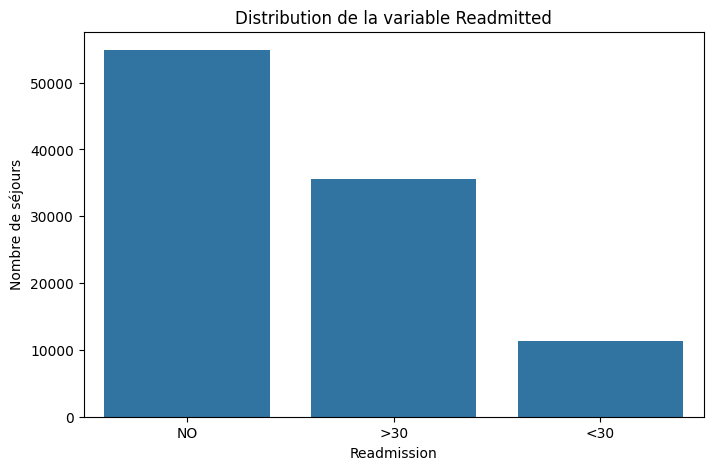

In [16]:
# Visualisation de la variable cible

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Distribution de la variable Readmitted")
plt.xlabel("Readmission")
plt.ylabel("Nombre de séjours")

plt.show()

## 2.9 Analyse des variables numériques importantes

Nous allons analyser plusieurs variables numériques liées au séjour
hospitalier et à l'utilisation des services de santé :

- `time_in_hospital`
- `num_lab_procedures`
- `num_procedures`
- `num_medications`
- `number_outpatient`
- `number_emergency`
- `number_inpatient`
- `number_diagnoses`

In [17]:
numeric_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


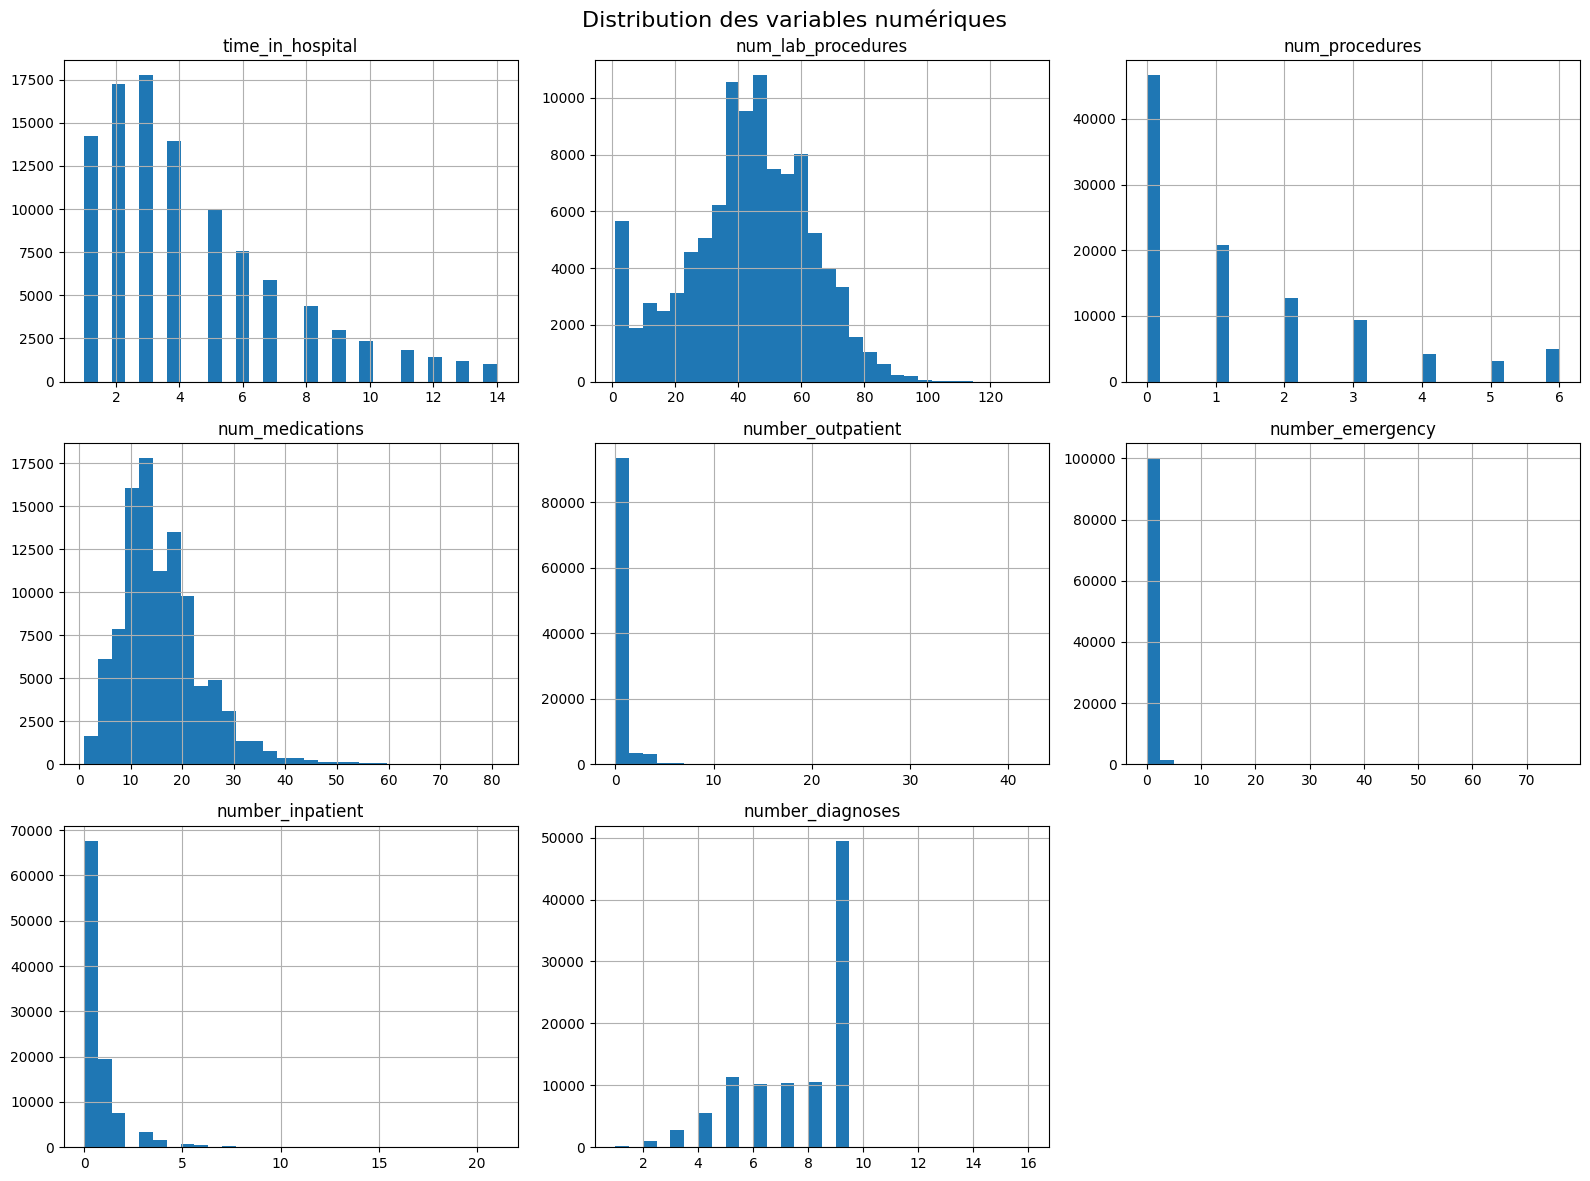

In [18]:
# Histogrammes des variables numériques

df[numeric_columns].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution des variables numériques",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Observation

Les distributions des variables numériques ne sont pas toutes similaires.

Certaines variables présentent une forte concentration de valeurs faibles
et quelques valeurs élevées.

Cela peut indiquer une asymétrie de distribution et la présence potentielle
de valeurs extrêmes.

Ces observations seront prises en compte lors de l'étape de Data
Preparation.

## 2.10 Analyse des valeurs aberrantes — Outliers

Les valeurs aberrantes doivent être étudiées avant de décider de les
supprimer ou de les transformer.

Nous allons utiliser des boxplots pour visualiser les valeurs extrêmes
des variables numériques.

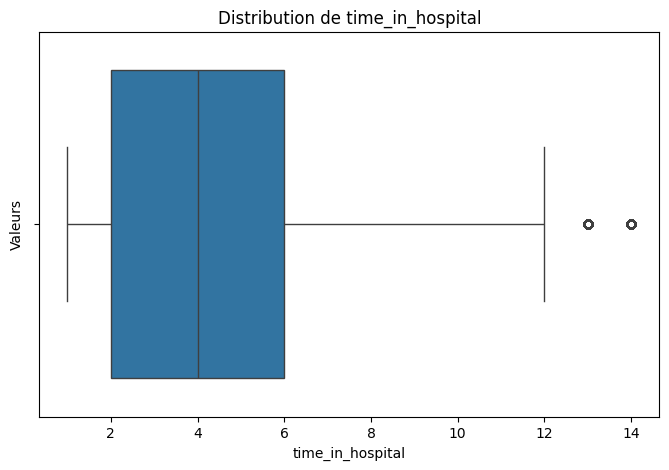

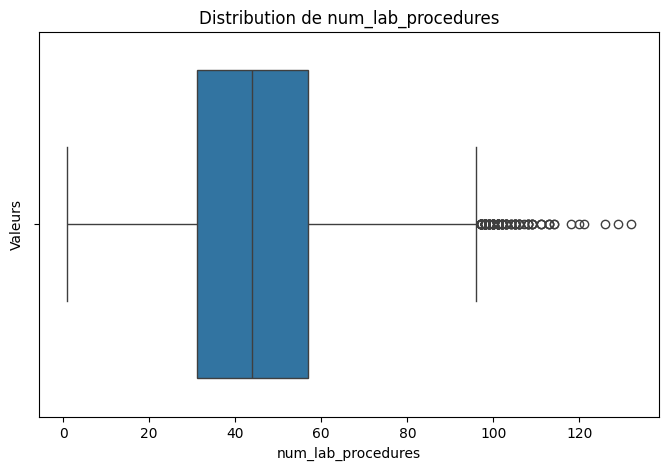

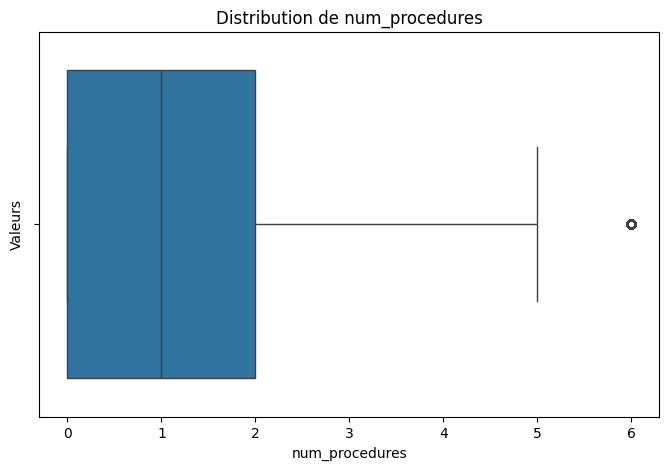

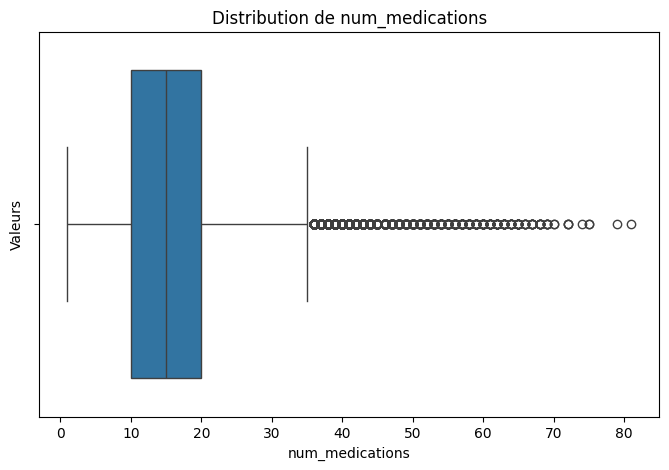

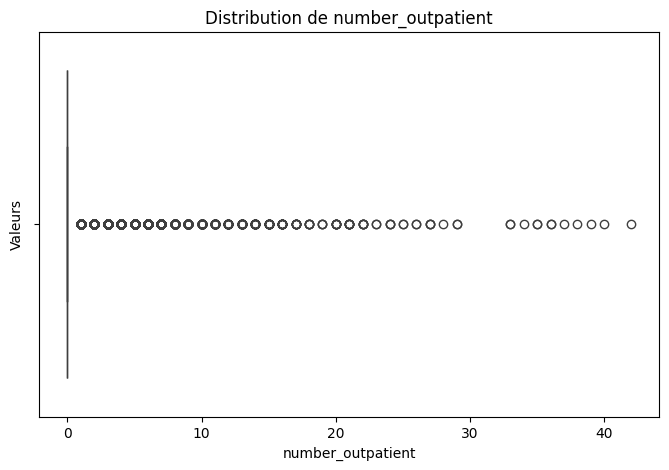

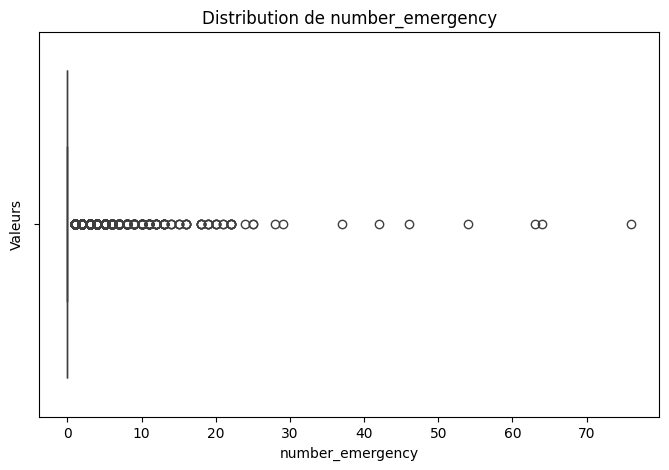

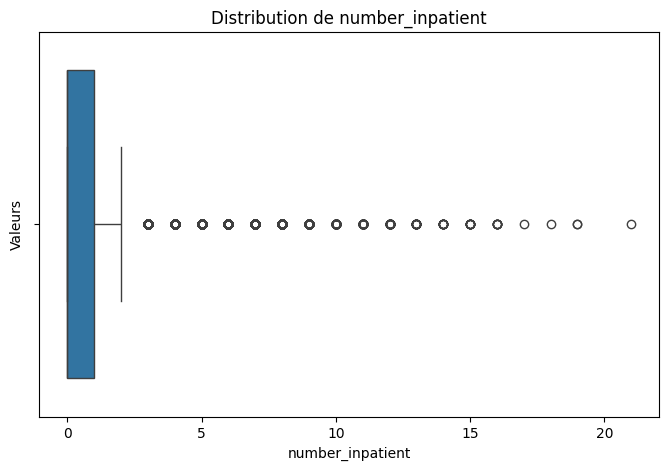

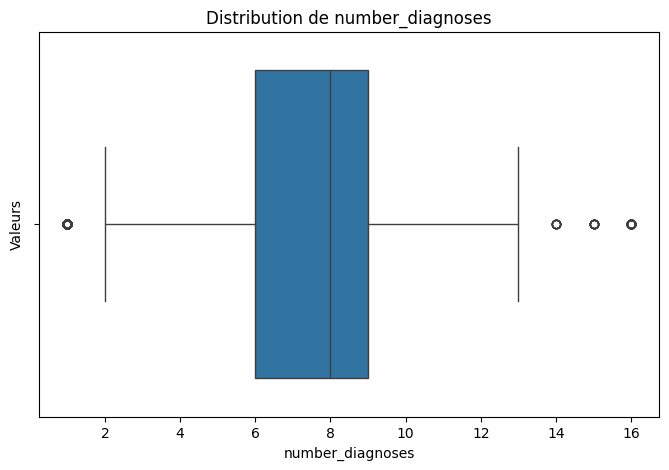

In [19]:

 # Visualisation des variables numériques

for column in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Distribution de {column}")
    plt.xlabel(column)
    plt.ylabel("Valeurs")

    plt.show()

### Observation

Les boxplots permettent d'identifier les observations situées très loin
de la majorité des valeurs.

Cependant, une valeur extrême dans un contexte hospitalier n'est pas
nécessairement une erreur.

Elle peut correspondre à un patient ayant utilisé fréquemment les services
de santé.

Les valeurs aberrantes devront donc être analysées avant toute suppression.

## 2.11 Matrice de corrélation

Nous allons analyser les relations entre les variables numériques.

La corrélation permet d'identifier les variables qui évoluent de manière
similaire.

Attention : une corrélation ne signifie pas nécessairement une relation
de causalité.

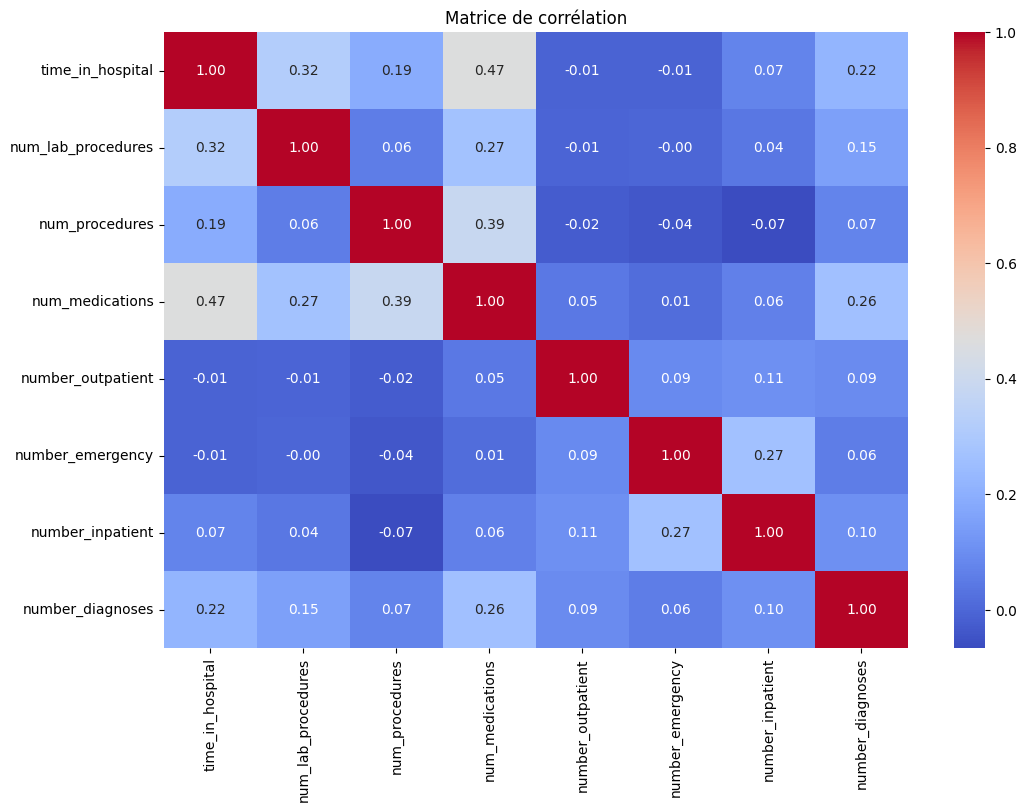

In [20]:
# Matrice de corrélation

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Matrice de corrélation")

plt.show()

## 2.12 Identification des problèmes de Data Quality

Après l'exploration initiale, plusieurs problèmes potentiels ont été
identifiés :

### 1. Valeurs manquantes

Certaines variables contiennent des valeurs manquantes ou le symbole `?`.

### 2. Variables catégorielles

Plusieurs variables sont catégorielles et devront être transformées
avant leur utilisation dans certains algorithmes.

### 3. Variables numériques

Les variables numériques présentent des distributions différentes et
certaines peuvent être fortement asymétriques.

### 4. Valeurs aberrantes

Certaines observations peuvent présenter des valeurs extrêmes qui
devront être analysées.

### 5. Variables d'identification

`encounter_id` et `patient_nbr` sont des identifiants et ne doivent pas
être considérés comme des caractéristiques médicales classiques.

### 6. Répétition des patients

Un même patient peut apparaître dans plusieurs séjours hospitaliers.
Cette situation doit être prise en compte afin d'éviter une fuite
d'information entre les ensembles d'entraînement et de test.

### 7. Déséquilibre de la variable cible

La réadmission dans les 30 jours est une classe minoritaire.

Ces différents problèmes seront traités dans l'étape suivante :
**Data Preparation**.

# 3. Data Preparation

> Ajouter une citation



Après avoir identifié les principaux problèmes de qualité des données, nous
passons à la préparation du dataset.

Cette étape consiste à traiter les valeurs manquantes, analyser les variables
problématiques et préparer progressivement les données pour les étapes de
segmentation et de classification.

Afin de conserver les données originales intactes, une copie du DataFrame
sera utilisée pour toutes les transformations.

In [21]:
# Création d'une copie du dataset original
df_clean = df.copy()

print("Dimensions du dataset :", df_clean.shape)

Dimensions du dataset : (101766, 50)


## 3.1 Traitement des valeurs manquantes

Lors de l'exploration des données, nous avons constaté que certaines valeurs
manquantes sont représentées par le symbole `?`.

Ce symbole n'est pas automatiquement reconnu comme une valeur manquante par
Pandas.

Nous allons donc remplacer les `?` par `NaN` afin de pouvoir identifier et
traiter correctement les valeurs manquantes.

In [22]:
import numpy as np

# Remplacement des "?" par NaN
df_clean.replace("?", np.nan, inplace=True)

print("Les '?' ont été remplacés par NaN.")

Les '?' ont été remplacés par NaN.


### 3.1.1 Analyse des valeurs manquantes après conversion

Après avoir remplacé les `?` par `NaN`, nous calculons le nombre et le
pourcentage de valeurs manquantes pour chaque variable.

Cette analyse permettra de déterminer les stratégies de traitement adaptées
à chaque variable.

In [24]:
# Nombre de valeurs manquantes
missing_count = df_clean.isnull().sum()

# Pourcentage de valeurs manquantes
missing_percent = (missing_count / len(df_clean)) * 100

# Création d'un tableau récapitulatif
missing_table = pd.DataFrame({
    "Valeurs_manquantes": missing_count,
    "Pourcentage": missing_percent
})

# Garder uniquement les colonnes ayant des valeurs manquantes
missing_table = missing_table[
    missing_table["Valeurs_manquantes"] > 0
]

# Trier de la plus forte proportion à la plus faible
missing_table = missing_table.sort_values(
    by="Pourcentage",
    ascending=False
)

missing_table

,Valeurs_manquantes,Pourcentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


### 3.1.2 Analyse des variables fortement incomplètes

L'analyse des valeurs manquantes montre que certaines variables présentent
un taux élevé de données manquantes.

Cependant, un taux élevé de valeurs manquantes ne signifie pas automatiquement
que la variable doit être supprimée. La décision dépend également de la
signification de la variable et de son intérêt pour l'analyse.

Nous examinons donc séparément les variables les plus concernées.

In [25]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(f"\n{col}")
    print("Valeurs manquantes :", df_clean[col].isnull().sum())
    print("Nombre de modalités :", df_clean[col].nunique())
    print(df_clean[col].value_counts().head(10))


diag_1
Valeurs manquantes : 21
Nombre de modalités : 716
diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

diag_2
Valeurs manquantes : 358
Nombre de modalités : 748
diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
496    3305
599    3288
403    2823
414    2650
411    2566
Name: count, dtype: int64

diag_3
Valeurs manquantes : 1423
Nombre de modalités : 789
diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
414     3664
496     2605
403     2357
585     1992
272     1969
Name: count, dtype: int64


### 3.1.3 Traitement des valeurs manquantes des diagnostics

Les variables `diag_1`, `diag_2` et `diag_3` présentent relativement peu
de valeurs manquantes par rapport à la taille totale du dataset.

Afin de conserver les séjours concernés et d'éviter de supprimer des
observations pour lesquelles seule l'information diagnostique est absente,
les valeurs manquantes sont remplacées par la catégorie `Unknown`.

Le nombre élevé de modalités observé dans ces variables sera traité
ultérieurement lors de la préparation des variables pour les modèles.

In [26]:
diagnosis_columns = ["diag_1", "diag_2", "diag_3"]

for col in diagnosis_columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

# Vérification
df_clean[diagnosis_columns].isnull().sum()

,0
diag_1,0
diag_2,0
diag_3,0


### 3.1.4 Traitement de la variable `race`

La variable `race` présente environ 2,23 % de valeurs manquantes.

Afin de conserver les observations concernées sans attribuer artificiellement
une catégorie existante, les valeurs manquantes sont remplacées par la
catégorie `Unknown`.

In [27]:
df_clean["race"] = df_clean["race"].fillna("Unknown")

# Vérification
print(df_clean["race"].value_counts(dropna=False))
print("\nValeurs manquantes :", df_clean["race"].isnull().sum())

race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

Valeurs manquantes : 0


### 3.1.5 Traitement de la variable `weight`

La variable `weight` présente environ 96,86 % de valeurs manquantes.

La proportion de valeurs disponibles étant très faible, cette variable
ne peut pas être exploitée de manière fiable sur l'ensemble du dataset.

Nous décidons donc de supprimer `weight` du jeu de données préparé.

In [28]:
df_clean.drop(columns=["weight"], inplace=True)

print("Variable 'weight' supprimée.")
print("Dimensions :", df_clean.shape)

Variable 'weight' supprimée.
Dimensions : (101766, 49)


### 3.1.6 Traitement de `max_glu_serum` et `A1Cresult`

Les variables `max_glu_serum` et `A1Cresult` présentent une proportion
importante de valeurs manquantes.

Contrairement à `weight`, ces variables correspondent à des résultats
d'examens. Nous choisissons donc de conserver l'information sur l'absence
de résultat en créant une catégorie `Not measured`.

Cette approche permet de conserver les deux variables sans imputer
artificiellement un résultat médical.

In [29]:
df_clean["max_glu_serum"] = df_clean["max_glu_serum"].fillna("Not measured")
df_clean["A1Cresult"] = df_clean["A1Cresult"].fillna("Not measured")

print("max_glu_serum :")
print(df_clean["max_glu_serum"].value_counts(dropna=False))

print("\nA1Cresult :")
print(df_clean["A1Cresult"].value_counts(dropna=False))

max_glu_serum :
max_glu_serum
Not measured    96420
Norm             2597
>200             1485
>300             1264
Name: count, dtype: int64

A1Cresult :
A1Cresult
Not measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64


### 3.1.7 Traitement de `medical_specialty`

La variable `medical_specialty` présente environ 49 % de valeurs manquantes.

La spécialité médicale peut néanmoins apporter une information utile.
Nous choisissons donc de conserver cette variable et de remplacer les
valeurs manquantes par la catégorie `Unknown`.

In [30]:
df_clean["medical_specialty"] = (
    df_clean["medical_specialty"].fillna("Unknown")
)

print(df_clean["medical_specialty"].value_counts().head(15))

medical_specialty
Unknown                            49949
InternalMedicine                   14635
Emergency/Trauma                    7565
Family/GeneralPractice              7440
Cardiology                          5352
Surgery-General                     3099
Nephrology                          1613
Orthopedics                         1400
Orthopedics-Reconstructive          1233
Radiologist                         1140
Pulmonology                          871
Psychiatry                           854
Urology                              685
ObstetricsandGynecology              671
Surgery-Cardiovascular/Thoracic      652
Name: count, dtype: int64


In [31]:
print("Nombre de modalités :", df_clean["payer_code"].nunique())

print("\nDistribution :")
print(df_clean["payer_code"].value_counts(dropna=False))

Nombre de modalités : 17

Distribution :
payer_code
NaN    40256
MC     32439
HM      6274
SP      5007
BC      4655
MD      3532
CP      2533
UN      2448
CM      1937
OG      1033
PO       592
DM       549
CH       146
WC       135
OT        95
MP        79
SI        55
FR         1
Name: count, dtype: int64


### 3.1.8 Traitement de la variable `payer_code`

La variable `payer_code` présente environ 39,6 % de valeurs manquantes et
17 modalités observées.

Compte tenu de la nature catégorielle de cette variable, une imputation
prédictive pourrait attribuer artificiellement un type de payeur sans
garantie que cette catégorie corresponde à la valeur réelle.

Nous choisissons donc de conserver la variable et de représenter les valeurs
manquantes par une catégorie `Unknown`. Cette stratégie permet de conserver
les observations tout en distinguant explicitement l'absence d'information.

In [32]:
# Remplacement des valeurs manquantes de payer_code
df_clean["payer_code"] = df_clean["payer_code"].fillna("Unknown")

# Vérification
print(df_clean["payer_code"].value_counts(dropna=False))

payer_code
Unknown    40256
MC         32439
HM          6274
SP          5007
BC          4655
MD          3532
CP          2533
UN          2448
CM          1937
OG          1033
PO           592
DM           549
CH           146
WC           135
OT            95
MP            79
SI            55
FR             1
Name: count, dtype: int64


### 3.1.9 Vérification finale des valeurs manquantes

Après avoir appliqué les différentes stratégies de traitement, nous vérifions
de nouveau la présence de valeurs manquantes dans le dataset.

Cette vérification permet de s'assurer que les traitements ont été correctement
appliqués et d'identifier d'éventuelles variables nécessitant encore une
intervention.

In [33]:
# Vérification des valeurs manquantes restantes
missing_after = df_clean.isnull().sum()

missing_after = missing_after[
    missing_after > 0
].sort_values(ascending=False)

print("Valeurs manquantes restantes :")
print(missing_after)

Valeurs manquantes restantes :
Series([], dtype: int64)


## 3.2 Analyse des identifiants et des séjours multiples

Le dataset contient deux variables d'identification :

- `encounter_id` : identifiant unique d'un séjour hospitalier ;
- `patient_nbr` : identifiant unique d'un patient.

Un même patient peut apparaître plusieurs fois dans le dataset s'il a effectué
plusieurs séjours hospitaliers.

Nous allons donc analyser le nombre de séjours et le nombre de patients uniques,
ainsi que la fréquence des séjours multiples par patient.

Cette analyse est importante pour éviter qu'un même patient apparaisse à la fois
dans les données d'entraînement et dans les données de test lors de la phase de
modélisation.

In [34]:
# Nombre de séjours et de patients uniques

n_encounters = df_clean["encounter_id"].nunique()
n_patients = df_clean["patient_nbr"].nunique()

print("Nombre total de lignes :", len(df_clean))
print("Nombre de séjours uniques :", n_encounters)
print("Nombre de patients uniques :", n_patients)

Nombre total de lignes : 101766
Nombre de séjours uniques : 101766
Nombre de patients uniques : 71518


### 3.2.1 Analyse du nombre de séjours par patient

Le dataset contient 101 766 séjours hospitaliers correspondant à
71 518 patients uniques.

Cette différence confirme qu'un même patient peut apparaître dans plusieurs
séjours hospitaliers.

Nous analysons donc le nombre de séjours par patient afin de mesurer
l'importance de ces répétitions avant de définir la stratégie de préparation
des données pour la modélisation.

In [35]:
# Nombre de séjours par patient
visits_per_patient = df_clean.groupby("patient_nbr").size()

print("Patients avec un seul séjour :",
      (visits_per_patient == 1).sum())

print("Patients avec plusieurs séjours :",
      (visits_per_patient > 1).sum())

print("\nStatistiques du nombre de séjours par patient :")
print(visits_per_patient.describe())

Patients avec un seul séjour : 54745
Patients avec plusieurs séjours : 16773

Statistiques du nombre de séjours par patient :
count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
dtype: float64


### 3.2.2 Gestion des patients avec plusieurs séjours

L'analyse montre qu'un même patient peut être associé à plusieurs séjours
hospitaliers.

Nous choisissons de conserver ces différents séjours car ils représentent
des événements hospitaliers distincts et contiennent des informations utiles.

Cependant, lors de la séparation des données en ensembles d'entraînement et
de test, les séjours appartenant à un même patient devront rester dans le
même ensemble.

Cette stratégie permettra de limiter le risque de fuite d'information entre
les données d'entraînement et de test.

In [36]:
# Vérification du nombre de séjours par patient
visits_per_patient = df_clean.groupby("patient_nbr").size()

# Nombre de patients avec un seul séjour
single_visit = (visits_per_patient == 1).sum()

# Nombre de patients avec plusieurs séjours
multiple_visits = (visits_per_patient > 1).sum()

print("Patients avec un seul séjour :", single_visit)
print("Patients avec plusieurs séjours :", multiple_visits)

# Vérification : aucune ligne n'est supprimée à cette étape
print("\nNombre de séjours conservés :", len(df_clean))

Patients avec un seul séjour : 54745
Patients avec plusieurs séjours : 16773

Nombre de séjours conservés : 101766


### 3.2.3 Traitement des variables d'identification

Les variables `encounter_id` et `patient_nbr` sont des identifiants et ne
constituent pas des caractéristiques cliniques à utiliser directement par
les modèles.

`encounter_id` identifie uniquement chaque séjour hospitalier. Il peut donc
être supprimé du jeu de données préparé.

`patient_nbr` identifie le patient. Cette variable sera conservée temporairement
afin de permettre ultérieurement une séparation des données par patient et
d'éviter qu'un même patient apparaisse à la fois dans les ensembles
d'entraînement et de test.

`patient_nbr` ne sera cependant pas utilisé comme variable explicative par
les modèles.

In [37]:
# Suppression de l'identifiant du séjour
df_clean.drop(columns=["encounter_id"], inplace=True)

# Vérification
print("Dimensions après suppression de encounter_id :", df_clean.shape)

print("\nencounter_id présent :",
      "encounter_id" in df_clean.columns)

print("patient_nbr présent :",
      "patient_nbr" in df_clean.columns)

Dimensions après suppression de encounter_id : (101766, 48)

encounter_id présent : False
patient_nbr présent : True


## 3.3 Analyse des variables catégorielles

Le dataset contient plusieurs variables catégorielles qui devront être
transformées avant leur utilisation par certains algorithmes de Machine Learning.

Cependant, toutes les variables catégorielles ne peuvent pas être traitées de
la même manière. Certaines possèdent peu de modalités, tandis que d'autres,
comme les variables de diagnostic, peuvent contenir plusieurs centaines de
catégories.

Nous commençons donc par identifier les variables catégorielles et analyser
leur cardinalité, c'est-à-dire le nombre de modalités différentes présentes
dans chaque variable.

In [38]:
# Identification des variables catégorielles
categorical_columns = df_clean.select_dtypes(
    include=["object"]
).columns.tolist()

print("Nombre de variables catégorielles :", len(categorical_columns))

print("\nVariables catégorielles :")
for col in categorical_columns:
    print("-", col)

Nombre de variables catégorielles : 36

Variables catégorielles :
- race
- gender
- age
- payer_code
- medical_specialty
- diag_1
- diag_2
- diag_3
- max_glu_serum
- A1Cresult
- metformin
- repaglinide
- nateglinide
- chlorpropamide
- glimepiride
- acetohexamide
- glipizide
- glyburide
- tolbutamide
- pioglitazone
- rosiglitazone
- acarbose
- miglitol
- troglitazone
- tolazamide
- examide
- citoglipton
- insulin
- glyburide-metformin
- glipizide-metformin
- glimepiride-pioglitazone
- metformin-rosiglitazone
- metformin-pioglitazone
- change
- diabetesMed
- readmitted


### 3.3.1 Analyse de la cardinalité des variables catégorielles

Le nombre de modalités d'une variable catégorielle influence la stratégie
d'encodage à utiliser.

Les variables ayant peu de modalités peuvent généralement être encodées
directement, tandis que les variables à forte cardinalité nécessitent une
attention particulière afin d'éviter la création d'un nombre excessif de
variables après encodage.

Nous calculons donc le nombre de modalités de chaque variable catégorielle.

In [39]:
# Calcul du nombre de modalités par variable catégorielle
cardinality = (
    df_clean[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
)

cardinality

,0
diag_3,790
diag_2,749
diag_1,717
medical_specialty,73
payer_code,18
age,10
race,6
glyburide-metformin,4
max_glu_serum,4
A1Cresult,4


### 3.3.2 Identification des variables à forte cardinalité

Les variables possédant un grand nombre de modalités nécessitent un traitement
spécifique avant leur utilisation dans les modèles.

Un encodage direct de ces variables pourrait générer un très grand nombre
de nouvelles colonnes.

Nous distinguons donc les variables à faible cardinalité des variables à
forte cardinalité avant de choisir les stratégies d'encodage.

In [40]:
# Seuil utilisé pour explorer la cardinalité
threshold = 20

low_cardinality = cardinality[cardinality <= threshold]
high_cardinality = cardinality[cardinality > threshold]

print("=== Variables à faible cardinalité ===")
print(low_cardinality)

print("\n=== Variables à forte cardinalité ===")
print(high_cardinality)

=== Variables à faible cardinalité ===
payer_code                  18
age                         10
race                         6
glyburide-metformin          4
max_glu_serum                4
A1Cresult                    4
metformin                    4
repaglinide                  4
nateglinide                  4
chlorpropamide               4
glimepiride                  4
glipizide                    4
pioglitazone                 4
glyburide                    4
acarbose                     4
rosiglitazone                4
miglitol                     4
insulin                      4
gender                       3
tolazamide                   3
readmitted                   3
acetohexamide                2
tolbutamide                  2
troglitazone                 2
metformin-rosiglitazone      2
metformin-pioglitazone       2
glimepiride-pioglitazone     2
glipizide-metformin          2
change                       2
diabetesMed                  2
citoglipton                  1


### 3.3.3 Identification et suppression des variables constantes

L'analyse de la cardinalité montre que les variables `examide` et
`citoglipton` ne possèdent qu'une seule modalité dans l'ensemble du dataset.

Une variable constante ne permet pas de différencier les observations et
n'apporte donc aucune information discriminante pour la segmentation ou
la classification.

Ces deux variables sont supprimées du jeu de données préparé.

In [41]:
for col in ["examide", "citoglipton"]:
    print(f"{col} :")
    print(df_clean[col].value_counts(dropna=False))
    print()

examide :
examide
No    101766
Name: count, dtype: int64

citoglipton :
citoglipton
No    101766
Name: count, dtype: int64



In [42]:
df_clean.drop(
    columns=["examide", "citoglipton"],
    inplace=True
)

print("Dimensions après suppression :", df_clean.shape)

Dimensions après suppression : (101766, 46)


### 3.3.4 Regroupement des codes de diagnostic

Les variables `diag_1`, `diag_2` et `diag_3` présentent une très forte
cardinalité, avec plusieurs centaines de codes différents.

Un encodage direct de ces codes générerait un nombre très important de
variables.

Afin de réduire cette cardinalité et d'obtenir des variables plus
interprétables, les codes de diagnostic seront regroupés en grandes
catégories.

Les variables originales seront conservées temporairement afin de vérifier
la transformation avant leur suppression.

In [43]:
for col in ["diag_1", "diag_2", "diag_3"]:
    print(f"\n--- {col} ---")
    print(df_clean[col].astype(str).head(20).tolist())


--- diag_1 ---
['250.83', '276', '648', '8', '197', '414', '414', '428', '398', '434', '250.7', '157', '428', '428', '518', '999', '410', '682', '402', '737']

--- diag_2 ---
['Unknown', '250.01', '250', '250.43', '157', '411', '411', '492', '427', '198', '403', '288', '250.43', '411', '998', '507', '411', '174', '425', '427']

--- diag_3 ---
['Unknown', '255', 'V27', '403', '250', '250', 'V45', '250', '38', '486', '996', '197', '250.6', '427', '627', '996', '414', '250', '416', '714']


### 3.3.5 Création de catégories de diagnostic

Les codes de diagnostic sont regroupés en catégories plus générales afin
de réduire le nombre de modalités.

Cette transformation permet de conserver l'information clinique principale
tout en obtenant une représentation plus adaptée aux algorithmes de Machine
Learning.

In [45]:
def categorize_diagnosis(code):

    # Valeur manquante déjà transformée précédemment
    if code == "Unknown":
        return "Unknown"

    code = str(code)

    # Codes commençant par V ou E
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    try:
        code = float(code)
    except ValueError:
        return "Other"

    # Diabète
    if 250 <= code < 251:
        return "Diabetes"

    # Circulatoire
    elif 390 <= code <= 459 or code == 785:
        return "Circulatory"

    # Respiratoire
    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"

    # Digestif
    elif 520 <= code <= 579 or code == 787:
        return "Digestive"

    # Blessures / empoisonnements
    elif 800 <= code <= 999:
        return "Injury"

    # Musculosquelettique
    elif 710 <= code <= 739:
        return "Musculoskeletal"

    # Génito-urinaire
    elif 580 <= code <= 629 or code == 788:
        return "Genitourinary"

    # Néoplasmes
    elif 140 <= code <= 239:
        return "Neoplasms"

    else:
        return "Other"

In [46]:
for col in ["diag_1", "diag_2", "diag_3"]:
    df_clean[col + "_group"] = df_clean[col].apply(categorize_diagnosis)

In [47]:
for col in ["diag_1_group", "diag_2_group", "diag_3_group"]:
    print(f"\n{col}")
    print(df_clean[col].value_counts())


diag_1_group
diag_1_group
Circulatory        30437
Other              18172
Respiratory        14423
Digestive           9475
Diabetes            8757
Injury              6974
Genitourinary       5117
Musculoskeletal     4957
Neoplasms           3433
Unknown               21
Name: count, dtype: int64

diag_2_group
diag_2_group
Circulatory        31881
Other              26553
Diabetes           12794
Respiratory        10895
Genitourinary       8376
Digestive           4170
Neoplasms           2547
Injury              2428
Musculoskeletal     1764
Unknown              358
Name: count, dtype: int64

diag_3_group
diag_3_group
Circulatory        30306
Other              29195
Diabetes           17157
Respiratory         7358
Genitourinary       6680
Digestive           3930
Injury              1946
Musculoskeletal     1915
Neoplasms           1856
Unknown             1423
Name: count, dtype: int64


### 3.3.6 Suppression des variables de diagnostic originales

Les variables `diag_1`, `diag_2` et `diag_3` ont été regroupées en catégories
de diagnostic plus générales.

Les nouvelles variables `diag_1_group`, `diag_2_group` et `diag_3_group`
conservent ainsi une information clinique plus synthétique tout en réduisant
fortement la cardinalité.

Les variables de diagnostic originales sont donc supprimées afin d'éviter
la redondance et la création d'un nombre trop important de variables lors
de l'encodage.

In [48]:
df_clean.drop(
    columns=["diag_1", "diag_2", "diag_3"],
    inplace=True
)

print("Dimensions après suppression :", df_clean.shape)

print("\nNouvelles variables de diagnostic :")
print([
    col for col in df_clean.columns
    if "diag" in col
])

Dimensions après suppression : (101766, 46)

Nouvelles variables de diagnostic :
['number_diagnoses', 'diag_1_group', 'diag_2_group', 'diag_3_group']


### 3.3.7 Analyse de la variable `medical_specialty`

La variable `medical_specialty` possède 73 modalités différentes.

Certaines spécialités peuvent être très peu représentées dans le dataset.
La conservation de toutes ces modalités lors de l'encodage pourrait augmenter
inutilement le nombre de variables.

Nous analysons donc leur fréquence afin d'identifier les spécialités les plus
fréquentes et les catégories rares.

In [49]:
specialty_counts = df_clean["medical_specialty"].value_counts()

print("Nombre de spécialités :", df_clean["medical_specialty"].nunique())

print("\nFréquence des spécialités :")
print(specialty_counts.to_string())

Nombre de spécialités : 73

Fréquence des spécialités :
medical_specialty
Unknown                                 49949
InternalMedicine                        14635
Emergency/Trauma                         7565
Family/GeneralPractice                   7440
Cardiology                               5352
Surgery-General                          3099
Nephrology                               1613
Orthopedics                              1400
Orthopedics-Reconstructive               1233
Radiologist                              1140
Pulmonology                               871
Psychiatry                                854
Urology                                   685
ObstetricsandGynecology                   671
Surgery-Cardiovascular/Thoracic           652
Gastroenterology                          564
Surgery-Vascular                          533
Surgery-Neuro                             468
PhysicalMedicineandRehabilitation         391
Oncology                                  348
Pediat

### 3.3.8 Regroupement des spécialités médicales rares

L'analyse de `medical_specialty` montre une forte concentration des observations
dans quelques spécialités, tandis que de nombreuses modalités sont très peu
représentées.

Afin de limiter la cardinalité et d'éviter la création de nombreuses variables
très rares lors de l'encodage, les spécialités représentant moins de 0,1 %
des observations sont regroupées dans une catégorie `Other`.

La catégorie `Unknown` est conservée séparément car elle représente les
observations pour lesquelles la spécialité médicale n'est pas renseignée.

In [50]:
# Seuil : 0,1 % du nombre total d'observations
threshold_specialty = 0.001 * len(df_clean)

print("Seuil de fréquence :", threshold_specialty)

# Fréquence de chaque spécialité
specialty_counts = df_clean["medical_specialty"].value_counts()

# Spécialités considérées comme rares
rare_specialties = specialty_counts[
    specialty_counts < threshold_specialty
].index

print("Nombre de spécialités rares :", len(rare_specialties))

Seuil de fréquence : 101.766
Nombre de spécialités rares : 46


In [51]:
df_clean["medical_specialty_group"] = (
    df_clean["medical_specialty"]
    .where(~df_clean["medical_specialty"].isin(rare_specialties), "Other")
)

print(
    df_clean["medical_specialty_group"]
    .value_counts()
    .to_string()
)

print(
    "\nNombre de modalités après regroupement :",
    df_clean["medical_specialty_group"].nunique()
)

medical_specialty_group
Unknown                              49949
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5352
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Other                                 1126
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology           

In [52]:
print("Avant regroupement :",
      df_clean["medical_specialty"].nunique())

print("Après regroupement :",
      df_clean["medical_specialty_group"].nunique())

Avant regroupement : 73
Après regroupement : 28


### 3.3.9 Finalisation du traitement de `medical_specialty`

> Ajouter une citation



Après regroupement des spécialités médicales rares, le nombre de modalités
de `medical_specialty` est passé de 73 à 28.

Les 46 spécialités représentant moins de 0,1 % des observations ont été
regroupées dans la catégorie `Other`.

La variable originale `medical_specialty` est maintenant supprimée et
remplacée par `medical_specialty_group`.

In [53]:
df_clean.drop(columns=["medical_specialty"], inplace=True)

print("medical_specialty présent :",
      "medical_specialty" in df_clean.columns)

print("medical_specialty_group présent :",
      "medical_specialty_group" in df_clean.columns)

print("Dimensions :", df_clean.shape)

medical_specialty présent : False
medical_specialty_group présent : True
Dimensions : (101766, 46)


## 3.4 Analyse des variables numériques

Après le traitement des variables catégorielles, nous analysons les variables numériques du dataset.

Certaines variables sont stockées sous forme numérique mais représentent en réalité des catégories codées par des nombres. C'est notamment le cas de `admission_type_id`, `discharge_disposition_id` et `admission_source_id`.

Ces variables doivent donc être distinguées des véritables variables quantitatives.


In [54]:
numeric_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Variables stockées sous forme numérique :")
for col in numeric_columns:
    print("-", col)

Variables stockées sous forme numérique :
- patient_nbr
- admission_type_id
- discharge_disposition_id
- admission_source_id
- time_in_hospital
- num_lab_procedures
- num_procedures
- num_medications
- number_outpatient
- number_emergency
- number_inpatient
- number_diagnoses


### 3.4.1 Distinction entre variables quantitatives et variables catégorielles codées

Certaines variables sont stockées sous forme numérique mais représentent
en réalité des catégories codées par des nombres.

C'est notamment le cas de `admission_type_id`, `discharge_disposition_id`
et `admission_source_id`.

Nous les séparons donc des véritables variables quantitatives.

In [55]:
coded_categorical = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

true_numeric = [
    col for col in numeric_columns
    if col not in coded_categorical
    and col != "patient_nbr"
]

print("Variables numériques quantitatives :")
print(true_numeric)

print("\nVariables catégorielles codées numériquement :")
print(coded_categorical)

Variables numériques quantitatives :
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables catégorielles codées numériquement :
['admission_type_id', 'discharge_disposition_id', 'admission_source_id']


### 3.5 Analyse des valeurs aberrantes

Certaines variables numériques peuvent présenter des valeurs extrêmes.
Dans ce dataset hospitalier, une valeur élevée n'est pas nécessairement
une erreur : elle peut correspondre à un patient ayant eu un séjour long,
de nombreuses procédures ou plusieurs consultations.

Les valeurs extrêmes ne seront donc pas supprimées automatiquement.
Elles seront analysées afin de vérifier leur cohérence.

In [56]:
df_clean[true_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


In [57]:
for col in true_numeric:
    print(
        f"{col:25s}",
        "Min =", df_clean[col].min(),
        "| Max =", df_clean[col].max()
    )

time_in_hospital          Min = 1 | Max = 14
num_lab_procedures        Min = 1 | Max = 132
num_procedures            Min = 0 | Max = 6
num_medications           Min = 1 | Max = 81
number_outpatient         Min = 0 | Max = 42
number_emergency          Min = 0 | Max = 76
number_inpatient          Min = 0 | Max = 21
number_diagnoses          Min = 1 | Max = 16


**Décision :**

Les valeurs extrêmes ne sont pas supprimées automatiquement, car elles
peuvent correspondre à des situations médicales réelles. Les variables
quantitatives sont donc conservées telles quelles.

### 3.6 Construction de la variable cible

L'objectif de la classification est de prédire si un patient sera
réadmis dans les 30 jours suivant son séjour hospitalier.

La variable `readmitted` possède trois modalités : `<30`, `>30` et `NO`.

Nous créons une nouvelle variable binaire `readmitted_30` :
- 1 : réadmission dans les 30 jours ;
- 0 : réadmission après plus de 30 jours ou absence de réadmission.

In [58]:
df_clean["readmitted_30"] = (
    df_clean["readmitted"] == "<30"
).astype(int)

print(df_clean["readmitted_30"].value_counts())

print("\nPourcentage :")
print(
    df_clean["readmitted_30"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Pourcentage :
readmitted_30
0    88.84
1    11.16
Name: proportion, dtype: float64


### 3.7 Suppression de la variable cible originale

Après la création de `readmitted_30`, la variable originale `readmitted`
n'est plus nécessaire.

Elle contient directement l'information utilisée pour construire la cible
et doit donc être supprimée des variables explicatives afin d'éviter une
fuite d'information (data leakage).


In [59]:
# Suppression de la variable cible originale
df_clean.drop(columns=["readmitted"], inplace=True, errors="ignore")

print("readmitted présent :", "readmitted" in df_clean.columns)
print("readmitted_30 présent :", "readmitted_30" in df_clean.columns)
print("Dimensions :", df_clean.shape)

readmitted présent : False
readmitted_30 présent : True
Dimensions : (101766, 46)


### 3.8 Vérification des doublons

Les séjours multiples d'un même patient ne sont pas considérés comme des
doublons, car ils correspondent à des événements hospitaliers distincts.

Nous vérifions uniquement la présence éventuelle de lignes complètement
identiques dans le dataset préparé.

In [60]:
duplicates = df_clean.duplicated().sum()

print("Nombre de lignes complètement dupliquées :", duplicates)

Nombre de lignes complètement dupliquées : 0


### 3.9 Vérification finale du dataset préparé

Avant de créer les jeux de données destinés aux modèles, nous vérifions les dimensions, les valeurs manquantes, le nombre de patients et la distribution de la cible.

In [61]:
print("=== DATASET PRÉPARÉ ===")

print("Nombre de lignes :", df_clean.shape[0])
print("Nombre de colonnes :", df_clean.shape[1])

print("\nNombre total de valeurs manquantes :")
print(df_clean.isnull().sum().sum())

print("\nNombre de patients uniques :")
print(df_clean["patient_nbr"].nunique())

print("\nDistribution de la cible :")
print(df_clean["readmitted_30"].value_counts())

print("\nTypes de variables :")
print(df_clean.dtypes.value_counts())

=== DATASET PRÉPARÉ ===
Nombre de lignes : 101766
Nombre de colonnes : 46

Nombre total de valeurs manquantes :
0

Nombre de patients uniques :
71518

Distribution de la cible :
readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Types de variables :
object    33
int64     13
Name: count, dtype: int64


In [62]:
#identifier les 14 895 valeurs manquantes
missing_final = df_clean.isnull().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print("Variables contenant encore des valeurs manquantes :")
print(missing_final)

print("\nPourcentage :")
print(
    (missing_final / len(df_clean) * 100)
    .round(2)
)

Variables contenant encore des valeurs manquantes :
Series([], dtype: int64)

Pourcentage :
Series([], dtype: float64)


### Aperçu final du dataset préparé

Nous affichons quelques lignes du dataset afin de vérifier sa structure finale avant de préparer les données pour la classification et la segmentation.

In [63]:
df_clean.head()

,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,diag_1_group,diag_2_group,diag_3_group,medical_specialty_group,readmitted_30
0,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,41,0,1,0,0,0,1,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Diabetes,Unknown,Unknown,Pediatrics-Endocrinology,0
1,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,59,0,18,0,0,0,9,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,Other,Diabetes,Other,Unknown,0
2,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,11,5,13,2,0,1,6,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,Other,Diabetes,Other,Unknown,0
3,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,44,1,16,0,0,0,7,Not measured,Not measured,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,Other,Diabetes,Circulatory,Unknown,0
4,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,51,0,8,0,0,0,5,Not measured,Not measured,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,Neoplasms,Neoplasms,Diabetes,Unknown,0


### 3.10 Création des datasets pour la classification et la segmentation

À partir du dataset préparé, nous créons deux copies :
- `df_classification` pour la prédiction de la réadmission à 30 jours ;
- `df_segmentation` pour la segmentation des patients.

Les transformations comme l'encodage et la standardisation seront réalisées plus tard,
dans la phase de modélisation.

In [64]:
df_classification = df_clean.copy()
df_segmentation = df_clean.copy()

print("Classification :", df_classification.shape)
print("Segmentation :", df_segmentation.shape)

Classification : (101766, 46)
Segmentation : (101766, 46)


### 3.10.1 Préparation du dataset pour la classification

Pour la classification, la variable cible est `readmitted_30`.

Nous séparons :
- `y` : la variable cible à prédire ;
- `X` : les variables explicatives ;
- `groups` : l'identifiant du patient, conservé séparément pour effectuer plus tard une séparation des données au niveau du patient.

La variable `patient_nbr` ne sera donc pas utilisée comme variable explicative.


In [65]:
# S'assurer que la colonne cible existe
if "readmitted_30" not in df_classification.columns:
    if "readmitted" in df_classification.columns:
        df_classification["readmitted_30"] = (df_classification["readmitted"] == "<30").astype(int)
        # Supprimer la colonne originale pour éviter le data leakage
        df_classification.drop(columns=["readmitted"], inplace=True, errors="ignore")
    else:
        raise KeyError("La colonne cible 'readmitted_30' ou 'readmitted' est introuvable.")

y = df_classification["readmitted_30"].copy()
groups = df_classification["patient_nbr"].copy()
X = df_classification.drop(
    columns=["readmitted_30", "patient_nbr"]
)

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)
print("Nombre de patients uniques :", groups.nunique())

Dimensions de X : (101766, 44)
Dimensions de y : (101766,)
Nombre de patients uniques : 71518


### 3.10.2 Séparation Train / Test par patient

Afin d'éviter qu'un même patient soit présent à la fois dans les données
d'entraînement et de test, la séparation est réalisée en utilisant
`patient_nbr` comme groupe.

Ainsi, tous les séjours appartenant à un même patient sont affectés
soit au jeu d'entraînement, soit au jeu de test.

In [66]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (81613, 44)
X_test : (20153, 44)
y_train : (81613,)
y_test : (20153,)


### 3.10.3 Vérification de la séparation par patient

Après la séparation des données, nous vérifions qu'aucun patient n'est présent
à la fois dans le jeu d'entraînement et dans le jeu de test.

Cette vérification permet d'éviter une fuite d'information entre les deux jeux,
car un même patient peut avoir plusieurs séjours hospitaliers.

In [67]:
#vérifie qu'il n'y a aucun patient commun
patients_communs = set(groups_train).intersection(set(groups_test))

print(
    "Nombre de patients présents dans Train ET Test :",
    len(patients_communs)
)

Nombre de patients présents dans Train ET Test : 0


### 3.10.4 Vérification de la distribution de la cible

Nous vérifions la distribution de la variable cible `readmitted_30` dans les
jeux d'entraînement et de test.

Cette étape permet de vérifier que les patients réadmis dans les 30 jours
(classe 1) restent représentés dans les deux ensembles après la séparation
par patient.

La classe 1 étant minoritaire, ce déséquilibre devra être pris en compte lors
de l'entraînement et de l'évaluation des modèles de classification.

In [68]:
print("Distribution TRAIN :")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nDistribution TEST :")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Distribution TRAIN :
readmitted_30
0    88.72
1    11.28
Name: proportion, dtype: float64

Distribution TEST :
readmitted_30
0    89.33
1    10.67
Name: proportion, dtype: float64


**Interprétation :**

La classe correspondant à une réadmission dans les 30 jours est minoritaire
dans les deux ensembles : elle représente environ 11 % des observations.

Les proportions restent proches entre les jeux d'entraînement et de test.
Le déséquilibre de la cible devra être pris en compte lors de la modélisation
et de l'évaluation des modèles.

## 3.11 Préparation du dataset pour la segmentation

Le deuxième objectif du projet consiste à identifier des profils similaires
à partir des données hospitalières.

Dans le dataset, une ligne correspond à un séjour hospitalier. Un même patient
peut donc apparaître plusieurs fois. La segmentation réalisée ici correspond
donc à une segmentation des profils de séjours hospitaliers.

La variable cible `readmitted_30` ne doit pas être utilisée pour construire
les clusters. Elle est conservée séparément afin de pouvoir analyser, après
la segmentation, le taux de réadmission dans chaque cluster.

L'identifiant `patient_nbr` est également conservé séparément, mais il ne sera
pas utilisé comme variable pour construire les clusters.

### 3.11.1 Création du dataset de segmentation

Nous créons une nouvelle copie de `df_clean` destinée spécifiquement à la
segmentation.

Cette copie permet de préparer les données du clustering sans modifier le
dataset nettoyé original.

In [69]:
df_segmentation = df_clean.copy()

print("Dimensions avant préparation :", df_segmentation.shape)

print(
    "readmitted_30 présent :",
    "readmitted_30" in df_segmentation.columns
)

print(
    "patient_nbr présent :",
    "patient_nbr" in df_segmentation.columns
)

Dimensions avant préparation : (101766, 46)
readmitted_30 présent : True
patient_nbr présent : True


### 3.11.2 Séparation des variables non utilisées pour le clustering

La variable `readmitted_30` est conservée séparément dans
`readmission_for_analysis`.

Elle ne sera pas utilisée pour construire les clusters, mais permettra
d'étudier le taux de réadmission dans chaque cluster après la segmentation.

L'identifiant `patient_nbr` est également conservé séparément pour assurer
la traçabilité des observations.

Ces deux variables sont ensuite retirées des caractéristiques utilisées pour
le clustering.

In [70]:
# Conservation de la cible pour l'analyse après clustering
readmission_for_analysis = (
    df_segmentation["readmitted_30"].copy()
)

# Conservation de l'identifiant patient
patient_ids_segmentation = (
    df_segmentation["patient_nbr"].copy()
)

# Suppression de ces deux variables des features de clustering
df_segmentation = df_segmentation.drop(
    columns=["readmitted_30", "patient_nbr"]
)

print(
    "Dimensions du dataset de segmentation :",
    df_segmentation.shape
)

Dimensions du dataset de segmentation : (101766, 44)


### 3.11.3 Vérification du dataset de segmentation

Nous vérifions que `readmitted_30` et `patient_nbr` ne sont plus présents
parmi les variables utilisées pour construire les clusters.

Nous vérifions également que les informations correspondantes ont bien été
conservées séparément pour permettre l'analyse des résultats après le
clustering.

In [72]:
print(
    "readmitted_30 dans les features :",
    "readmitted_30" in df_segmentation.columns
)

print(
    "patient_nbr dans les features :",
    "patient_nbr" in df_segmentation.columns
)

print(
    "Nombre de valeurs de réadmission conservées :",
    len(readmission_for_analysis)
)

print(
    "Nombre d'identifiants patients conservés :",
    len(patient_ids_segmentation)
)

print(
    "Dimensions finales pour la segmentation :",
    df_segmentation.shape
)

readmitted_30 dans les features : False
patient_nbr dans les features : False
Nombre de valeurs de réadmission conservées : 101766
Nombre d'identifiants patients conservés : 101766
Dimensions finales pour la segmentation : (101766, 44)


In [73]:
df_segmentation.shape


(101766, 44)

In [74]:
missing_final = df_clean.isnull().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print("Valeurs manquantes restantes :")
print(missing_final)

print("\nNombre total :", df_clean.isnull().sum().sum())

Valeurs manquantes restantes :
Series([], dtype: int64)

Nombre total : 0


## 3.12 Préparation des variables pour la modélisation

Avant la modélisation, les variables doivent être traitées selon leur nature.

Le dataset contient trois principaux types de variables :

- des variables numériques quantitatives, comme `time_in_hospital` ou
  `num_medications` ;
- des variables catégorielles nominales, comme `race`, `gender` ou
  `medical_specialty_group` ;
- une variable catégorielle ordinale : `age`.

Certaines variables sont enregistrées sous forme numérique mais représentent
en réalité des catégories :

- `admission_type_id`
- `discharge_disposition_id`
- `admission_source_id`

Elles doivent donc être considérées comme des variables catégorielles et non
comme des variables quantitatives.

Cette distinction permet de choisir un prétraitement adapté aux deux objectifs
du projet : la classification et la segmentation.

### 3.12.1 Identification des types de variables pour la classification

Pour la classification, les variables explicatives sont séparées en variables
numériques, catégorielles nominales et ordinales.

Les trois variables d'identification du type d'admission, de sortie et de
source d'admission sont traitées comme des catégories même si elles sont
stockées sous forme numérique.

La variable `age` est traitée séparément car les tranches d'âge possèdent
un ordre naturel.

In [75]:
# Variables catégorielles codées avec des nombres
coded_categorical = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# Variables catégorielles classiques
categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Ajout des variables catégorielles codées numériquement
categorical_columns = list(
    dict.fromkeys(categorical_columns + coded_categorical)
)

# age sera traité séparément comme variable ordinale
if "age" in categorical_columns:
    categorical_columns.remove("age")

# Variables réellement numériques
numeric_columns = [
    col
    for col in X_train.select_dtypes(include="number").columns
    if col not in coded_categorical
]

print("=== CLASSIFICATION ===")

print("\nNombre de variables numériques :",
      len(numeric_columns))

print("Nombre de variables catégorielles :",
      len(categorical_columns))

print("Variable ordinale : age")

print("\nVariables numériques :")
print(numeric_columns)

print("\nVariables catégorielles :")
print(categorical_columns)

=== CLASSIFICATION ===

Nombre de variables numériques : 8
Nombre de variables catégorielles : 35
Variable ordinale : age

Variables numériques :
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables catégorielles :
['race', 'gender', 'payer_code', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'medical_specialty_group', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


### 3.12.2 Traitement de la variable `age`

La variable `age` est représentée sous forme de tranches d'âge telles que
`[0-10)`, `[10-20)`, ..., `[90-100)`.

Ces catégories possèdent un ordre naturel. La variable `age` sera donc traitée
comme une variable ordinale.

Un ordre numérique est associé aux différentes tranches afin de conserver
l'information liée à la progression de l'âge.

In [76]:
age_mapping = {
    "[0-10)": 0,
    "[10-20)": 1,
    "[20-30)": 2,
    "[30-40)": 3,
    "[40-50)": 4,
    "[50-60)": 5,
    "[60-70)": 6,
    "[70-80)": 7,
    "[80-90)": 8,
    "[90-100)": 9
}

print("Encodage ordinal prévu pour age :")

for age_range, value in age_mapping.items():
    print(age_range, "->", value)

Encodage ordinal prévu pour age :
[0-10) -> 0
[10-20) -> 1
[20-30) -> 2
[30-40) -> 3
[40-50) -> 4
[50-60) -> 5
[60-70) -> 6
[70-80) -> 7
[80-90) -> 8
[90-100) -> 9


### 3.12.3 Définition du préprocesseur pour la classification

Afin de préparer les données pour la classification, les transformations sont définies en fonction de la nature des variables.

La variable `age`, qui représente des intervalles d'âge ordonnés, est transformée en une variable numérique ordinale à l'aide du mapping défini précédemment.

Les variables catégorielles nominales sont transformées à l'aide du **One-Hot Encoding**. Cette méthode crée des variables binaires pour représenter les différentes modalités sans introduire artificiellement d'ordre entre les catégories.

Les variables `admission_type_id`, `discharge_disposition_id` et `admission_source_id`, bien que représentées par des valeurs numériques, correspondent à des catégories et sont donc également traitées comme des variables catégorielles.

Les variables numériques sont standardisées à l'aide de **StandardScaler** afin de les placer sur des échelles comparables.

Ces différentes transformations sont regroupées dans un `ColumnTransformer`. Le préprocesseur sera ajusté uniquement sur le jeu d'entraînement afin d'éviter toute fuite d'information vers le jeu de test.

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Copie pour ne pas modifier les données originales
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

# Transformation ordinale de l'âge
X_train_prep["age"] = X_train_prep["age"].map(age_mapping)
X_test_prep["age"] = X_test_prep["age"].map(age_mapping)

# age devient une variable numérique ordinale
numeric_columns_class = numeric_columns + ["age"]

# Création du préprocesseur
preprocessor_classification = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_columns_class
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_columns
        )
    ]
)

print("Préprocesseur de classification créé.")

Préprocesseur de classification créé.


### 3.12.4 Application de l'encodage et de la standardisation — Classification

Afin de préparer les données pour les algorithmes de classification, les transformations définies précédemment sont appliquées aux jeux d'entraînement et de test.

Les variables catégorielles sont transformées à l'aide du **One-Hot Encoding**, tandis que les variables numériques sont **standardisées** afin de les placer sur des échelles comparables.

Le préprocesseur est ajusté uniquement sur le jeu d'entraînement (`X_train`) à l'aide de `fit_transform()`. Le jeu de test (`X_test`) est ensuite transformé avec le même préprocesseur à l'aide de `transform()`.

Cette approche permet d'éviter toute **fuite d'information (data leakage)** entre les données d'entraînement et les données de test.

Après transformation, le nombre d'observations reste inchangé :

- Jeu d'entraînement : **81 613 observations**
- Jeu de test : **20 153 observations**

Le nombre de variables passe de **44 à 222**, principalement en raison du One-Hot Encoding des variables catégorielles.

Les jeux d'entraînement et de test possèdent finalement le même nombre de variables (**222**) et sont désormais préparés pour la phase de modélisation.

In [78]:
X_train_transformed = preprocessor_classification.fit_transform(
    X_train_prep
)

X_test_transformed = preprocessor_classification.transform(
    X_test_prep
)

print("Dimensions X_train avant :", X_train.shape)
print("Dimensions X_train après :", X_train_transformed.shape)

print("Dimensions X_test avant :", X_test.shape)
print("Dimensions X_test après :", X_test_transformed.shape)

Dimensions X_train avant : (81613, 44)
Dimensions X_train après : (81613, 222)
Dimensions X_test avant : (20153, 44)
Dimensions X_test après : (20153, 222)


### 3.12.5 Identification des variables pour la segmentation

Pour la segmentation, nous appliquons la même distinction entre variables
numériques, catégorielles nominales et ordinales.

La variable cible `readmitted_30` et l'identifiant `patient_nbr` ont déjà été
retirés du dataset utilisé pour le clustering.

Ils ne participeront donc pas à la construction des clusters.

In [79]:
# Variables catégorielles de la segmentation
seg_categorical_columns = (
    df_segmentation
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

# Ajout des catégories codées numériquement
seg_categorical_columns = list(
    dict.fromkeys(
        seg_categorical_columns + coded_categorical
    )
)

# age est traité séparément
if "age" in seg_categorical_columns:
    seg_categorical_columns.remove("age")

# Variables réellement numériques
seg_numeric_columns = [
    col
    for col in df_segmentation.select_dtypes(
        include="number"
    ).columns
    if col not in coded_categorical
]

print("=== SEGMENTATION ===")

print("\nNombre de variables numériques :",
      len(seg_numeric_columns))

print("Nombre de variables catégorielles :",
      len(seg_categorical_columns))

print("Variable ordinale : age")

print("\nVariables numériques :")
print(seg_numeric_columns)

print("\nVariables catégorielles :")
print(seg_categorical_columns)

=== SEGMENTATION ===

Nombre de variables numériques : 8
Nombre de variables catégorielles : 35
Variable ordinale : age

Variables numériques :
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Variables catégorielles :
['race', 'gender', 'payer_code', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'medical_specialty_group', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']


### 3.12.6 Vérification de la répartition des variables

Nous vérifions que toutes les variables du dataset de segmentation ont bien été
affectées à l'un des trois groupes : numérique, catégoriel nominal ou ordinal.

Cette vérification permet d'éviter qu'une variable soit oubliée avant la
modélisation.

In [80]:
n_numeric = len(seg_numeric_columns)
n_categorical = len(seg_categorical_columns)
n_ordinal = 1 if "age" in df_segmentation.columns else 0

total_identified = (
    n_numeric
    + n_categorical
    + n_ordinal
)

print("Variables numériques :", n_numeric)
print("Variables catégorielles :", n_categorical)
print("Variables ordinales :", n_ordinal)

print("\nTotal identifié :", total_identified)
print(
    "Nombre de colonnes dans df_segmentation :",
    df_segmentation.shape[1]
)

print(
    "\nToutes les variables sont prises en compte :",
    total_identified == df_segmentation.shape[1]
)

Variables numériques : 8
Variables catégorielles : 35
Variables ordinales : 1

Total identifié : 44
Nombre de colonnes dans df_segmentation : 44

Toutes les variables sont prises en compte : True


### 3.12.7 Vérification des valeurs manquantes

Avant de passer à la modélisation, nous vérifions une dernière fois l'absence
de valeurs manquantes dans les données utilisées pour la classification et
la segmentation.

In [81]:
print(
    "Valeurs manquantes dans X_train :",
    X_train.isnull().sum().sum()
)

print(
    "Valeurs manquantes dans X_test :",
    X_test.isnull().sum().sum()
)

print(
    "Valeurs manquantes dans df_segmentation :",
    df_segmentation.isnull().sum().sum()
)

Valeurs manquantes dans X_train : 0
Valeurs manquantes dans X_test : 0
Valeurs manquantes dans df_segmentation : 0


### 3.12.8 Définition du préprocesseur pour la segmentation

Après avoir identifié et vérifié les différents types de variables, nous
définissons le préprocesseur destiné à la segmentation.

La variable `age` est transformée en variable numérique ordinale à l'aide du
mapping défini précédemment.

Les variables catégorielles nominales sont transformées par One-Hot Encoding,
tandis que les variables numériques sont standardisées avec `StandardScaler`.

La standardisation est particulièrement importante pour les algorithmes de
clustering basés sur les distances, comme K-Means.

Les variables `readmitted_30`, `readmitted` et `patient_nbr` ne doivent pas
participer à la construction des clusters.

In [82]:
# Copie des données destinées à la segmentation
df_segmentation_prep = df_segmentation.copy()

# Vérification anti-leakage
print("readmitted présent :",
      "readmitted" in df_segmentation_prep.columns)

print("readmitted_30 présent :",
      "readmitted_30" in df_segmentation_prep.columns)

print("patient_nbr présent :",
      "patient_nbr" in df_segmentation_prep.columns)

# Transformation ordinale de age
df_segmentation_prep["age"] = (
    df_segmentation_prep["age"].map(age_mapping)
)

# age rejoint les variables numériques
seg_numeric_with_age = seg_numeric_columns + ["age"]

# Préprocesseur pour la segmentation
preprocessor_segmentation = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            seg_numeric_with_age
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            seg_categorical_columns
        )
    ]
)

print("\nPréprocesseur de segmentation créé.")

readmitted présent : False
readmitted_30 présent : False
patient_nbr présent : False

Préprocesseur de segmentation créé.


### 3.12.9 Application de l'encodage et de la standardisation — Segmentation

Le préprocesseur défini précédemment est appliqué au dataset destiné à la
segmentation.

Les variables catégorielles sont transformées par One-Hot Encoding et les
variables numériques sont standardisées.

Le nombre d'observations doit rester inchangé après la transformation, tandis
que le nombre de variables peut augmenter en raison du One-Hot Encoding.

La matrice obtenue sera utilisée dans la phase de modélisation pour construire
les clusters.

In [83]:
X_segmentation_transformed = (
    preprocessor_segmentation.fit_transform(
        df_segmentation_prep
    )
)

print(
    "Dimensions avant transformation :",
    df_segmentation_prep.shape
)

print(
    "Dimensions après transformation :",
    X_segmentation_transformed.shape
)

print(
    "Nombre de lignes conservé :",
    X_segmentation_transformed.shape[0]
    == df_segmentation_prep.shape[0]
)

Dimensions avant transformation : (101766, 44)
Dimensions après transformation : (101766, 226)
Nombre de lignes conservé : True


### 3.12.10 Vérification finale des données préparées

Une vérification finale est réalisée afin de s'assurer que les données sont correctement préparées pour les deux objectifs du projet : la classification et la segmentation.

Pour la **classification**, nous vérifions que les jeux d'entraînement et de test possèdent le même nombre de variables après l'encodage et la standardisation.

Pour la **segmentation**, nous vérifions que le nombre d'observations reste inchangé après les transformations.

Nous vérifions également l'absence des variables `readmitted`, `readmitted_30` et `patient_nbr` parmi les caractéristiques utilisées pour construire les clusters. La variable `readmitted_30` est conservée séparément uniquement pour permettre l'analyse des clusters après leur construction.

Enfin, nous vérifions qu'aucun patient n'est présent simultanément dans les jeux d'entraînement et de test de la classification afin d'éviter toute fuite d'information.

Ces vérifications permettent de confirmer que les données sont prêtes pour la phase suivante du processus CRISP-DM : **Modeling**.

In [84]:
print("===== CLASSIFICATION =====")
print("X_train :", X_train_transformed.shape)
print("X_test :", X_test_transformed.shape)

print(
    "Même nombre de variables Train/Test :",
    X_train_transformed.shape[1] == X_test_transformed.shape[1]
)

print("\n===== SEGMENTATION =====")
print("X_segmentation :", X_segmentation_transformed.shape)

print(
    "Nombre de lignes conservé :",
    X_segmentation_transformed.shape[0] == df_segmentation.shape[0]
)

print("\n===== ANTI-LEAKAGE =====")
print("readmitted absent :",
      "readmitted" not in df_segmentation.columns)
print("readmitted_30 absent :",
      "readmitted_30" not in df_segmentation.columns)
print("patient_nbr absent :",
      "patient_nbr" not in df_segmentation.columns)

print(
    "Patients communs Train/Test :",
    len(set(groups_train).intersection(set(groups_test)))
)

===== CLASSIFICATION =====
X_train : (81613, 222)
X_test : (20153, 222)
Même nombre de variables Train/Test : True

===== SEGMENTATION =====
X_segmentation : (101766, 226)
Nombre de lignes conservé : True

===== ANTI-LEAKAGE =====
readmitted absent : True
readmitted_30 absent : True
patient_nbr absent : True
Patients communs Train/Test : 0


### 3.12.11 Réduction dimensionnelle par PCA pour la segmentation

Après l'encodage et la standardisation, les données destinées à la segmentation
contiennent 226 variables.

Afin de réduire la dimension des données tout en conservant une grande partie
de l'information, nous étudions l'utilisation d'une Analyse en Composantes
Principales (PCA).

La PCA transforme les variables initiales en nouvelles composantes principales
non corrélées, ordonnées selon la quantité de variance qu'elles expliquent.

Dans un premier temps, nous calculons la variance expliquée cumulée afin de
déterminer le nombre de composantes nécessaires pour conserver 95 % de la
variance totale.

La matrice originale transformée `X_segmentation_transformed` est conservée.
Une nouvelle matrice `X_segmentation_pca` sera créée afin de permettre, lors de
la phase de modélisation, de comparer la segmentation avec et sans PCA.

In [85]:
import numpy as np
from sklearn.decomposition import PCA

# Conversion en matrice dense pour PCA
if hasattr(X_segmentation_transformed, "toarray"):
    X_segmentation_dense = X_segmentation_transformed.toarray()
else:
    X_segmentation_dense = X_segmentation_transformed

print("Dimensions avant PCA :", X_segmentation_dense.shape)

# PCA initiale pour étudier la variance expliquée
pca_full = PCA()
pca_full.fit(X_segmentation_dense)

# Variance expliquée cumulée
cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# Nombre de composantes permettant de conserver au moins 95 % de la variance
n_components_95 = (
    np.argmax(cumulative_variance >= 0.95) + 1
)

print(
    "Nombre de composantes pour conserver 95 % de la variance :",
    n_components_95
)

print(
    "Variance expliquée cumulée :",
    cumulative_variance[n_components_95 - 1]
)

Dimensions avant PCA : (101766, 226)
Nombre de composantes pour conserver 95 % de la variance : 60
Variance expliquée cumulée : 0.9512093497457944


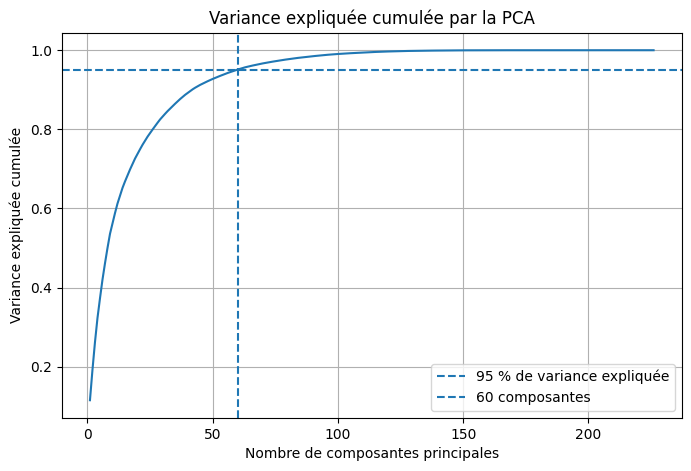

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95 % de variance expliquée"
)

plt.axvline(
    x=n_components_95,
    linestyle="--",
    label=f"{n_components_95} composantes"
)

plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par la PCA")
plt.legend()
plt.grid()
plt.show()

In [87]:
pca = PCA(
    n_components=n_components_95,
    random_state=42
)

X_segmentation_pca = pca.fit_transform(
    X_segmentation_dense
)

print(
    "Dimensions sans PCA :",
    X_segmentation_transformed.shape
)

print(
    "Dimensions avec PCA :",
    X_segmentation_pca.shape
)

print(
    "Variance totale conservée :",
    pca.explained_variance_ratio_.sum()
)

Dimensions sans PCA : (101766, 226)
Dimensions avec PCA : (101766, 60)
Variance totale conservée : 0.9512093497457945


### 3.12.12 Interprétation de la PCA

Avant l'application de la PCA, les données destinées à la segmentation
contenaient **226 variables** après l'encodage et la standardisation.

L'analyse de la variance expliquée cumulée montre que **60 composantes
principales** permettent de conserver environ **95,12 % de la variance totale**.

La PCA permet ainsi de réduire la dimension des données de **226 à 60
composantes**, tout en conservant la majeure partie de la variabilité présente
dans les données.

Pour la phase de modélisation, deux représentations des données sont conservées :

- `X_segmentation_transformed` : données encodées et standardisées sans PCA ;
- `X_segmentation_pca` : données réduites à 60 composantes principales.

Lors de la phase de Modeling, les résultats du clustering pourront être comparés
avec et sans PCA afin d'évaluer l'intérêt de la réduction dimensionnelle.

## 3.13 Export des données préparées

À l'issue de la phase de préparation, le dataset nettoyé est exporté afin de
conserver une version exploitable pour les étapes suivantes du projet.

Les différentes matrices préparées pour la classification et la segmentation
sont également conservées dans le notebook pour la phase de modélisation.

In [91]:
df_clean.to_csv(
    "diabetic_data_clean.csv",
    index=False
)

print("Dataset nettoyé exporté avec succès.")
print("Dimensions :", df_clean.shape)

print("\n===== CLASSIFICATION =====")
print("X_train_transformed :", X_train_transformed.shape)
print("X_test_transformed :", X_test_transformed.shape)

print("\n===== SEGMENTATION =====")
print("Sans PCA :", X_segmentation_transformed.shape)
print("Avec PCA :", X_segmentation_pca.shape)

Dataset nettoyé exporté avec succès.
Dimensions : (101766, 46)

===== CLASSIFICATION =====
X_train_transformed : (81613, 222)
X_test_transformed : (20153, 222)

===== SEGMENTATION =====
Sans PCA : (101766, 226)
Avec PCA : (101766, 60)


## 3.14 Conclusion de la phase Data Preparation

La phase de préparation des données a permis d'obtenir des données cohérentes
et adaptées aux deux objectifs du projet : la classification de la réadmission
à 30 jours et la segmentation des profils de séjours hospitaliers.

Les valeurs manquantes ont été traitées, les variables non pertinentes ou
constantes ont été supprimées et les variables à forte cardinalité, notamment
les diagnostics et la spécialité médicale, ont été regroupées. Les doublons
ont également été vérifiés.

Pour la **classification**, la variable cible binaire `readmitted_30` a été
créée afin d'identifier les réadmissions dans les 30 jours. Les données ont
été séparées en ensembles d'entraînement et de test par patient afin d'éviter
qu'un même patient soit présent dans les deux ensembles. Après encodage et
standardisation, les données de classification contiennent **222 variables**.

Pour la **segmentation**, `readmitted_30` et `patient_nbr` ont été exclus des
variables utilisées pour construire les clusters. La variable de réadmission
a été conservée séparément afin de permettre l'analyse des clusters après leur
construction. Après encodage et standardisation, les données de segmentation
contiennent **226 variables**.

Une Analyse en Composantes Principales (PCA) a ensuite été appliquée aux
données de segmentation. Elle permet de réduire la dimension de **226 à 60
composantes principales**, tout en conservant environ **95,12 % de la variance
totale**.

Deux représentations des données de segmentation sont donc disponibles pour
la modélisation : une version sans PCA et une version avec PCA.

Les données sont désormais prêtes pour la phase suivante du processus
CRISP-DM : **Modeling**.

## 4. Modeling

Cette étape consiste à construire les modèles de Machine Learning permettant de répondre aux deux objectifs Data Science définis précédemment.

Deux tâches de modélisation sont réalisées :

- **Clustering** : identifier des profils de séjours hospitaliers présentant des caractéristiques similaires.
- **Classification** : prédire la réadmission du patient dans les 30 jours suivant sa sortie.

Pour le clustering, nous utilisons les données préparées pour la segmentation, avec et sans réduction dimensionnelle par PCA.

Pour la classification, nous utilisons les données d'entraînement et de test préparées précédemment afin de construire et comparer plusieurs modèles.

Les performances des modèles seront ensuite analysées dans la phase **5. Evaluation** (qualité des clusters et des modèles, puis verdict par rapport aux objectifs BO1 et BO2).

### 4.1 Clustering

L'objectif du clustering est d'identifier des groupes de séjours hospitaliers présentant des caractéristiques similaires.

Contrairement à la classification, cette tâche est non supervisée : aucune variable cible n'est utilisée pour construire les clusters.

La variable `readmitted_30` est donc exclue de la construction des clusters. Elle pourra cependant être utilisée après le clustering afin d'analyser le taux de réadmission associé à chaque groupe.

Nous utilisons l'algorithme **K-Means**, qui nécessite de définir le nombre de clusters `k`.

Deux représentations des données seront comparées :

- les données encodées et standardisées sans PCA ;
- les données après réduction dimensionnelle par PCA.

#### 4.1.1 Choix du nombre de clusters

Avant d'appliquer K-Means, nous cherchons un nombre de clusters adapté aux données.

Pour cela, plusieurs valeurs de `k` sont testées.

Deux indicateurs sont utilisés :

- **l'inertie (Within-Cluster Sum of Squares)** : elle mesure la compacité des clusters ;
- **le coefficient de silhouette** : il mesure à la fois la cohésion des observations au sein de leur cluster et leur séparation par rapport aux autres clusters.

Ces indicateurs permettent de comparer différentes valeurs de `k` avant de choisir une configuration pour la suite du projet.

In [89]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Échantillon utilisé uniquement pour calculer le score de silhouette
sample_size = 10000

rng = np.random.RandomState(42)

sample_indices = rng.choice(
    X_segmentation_pca.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_segmentation_pca[sample_indices]

k_values = range(2, 9)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # K-Means sur toutes les observations
    labels = kmeans.fit_predict(X_segmentation_pca)

    inertias.append(kmeans.inertia_)

    # Silhouette calculée sur un échantillon
    sample_labels = labels[sample_indices]

    silhouette = silhouette_score(
        X_sample,
        sample_labels
    )

    silhouette_scores.append(silhouette)

    print(
        f"k={k} | "
        f"Inertie={kmeans.inertia_:.2f} | "
        f"Silhouette={silhouette:.4f}"
    )

k=2 | Inertie=1670909.89 | Silhouette=0.0828
k=3 | Inertie=1594425.86 | Silhouette=0.0640
k=4 | Inertie=1529221.56 | Silhouette=0.0591
k=5 | Inertie=1483508.69 | Silhouette=0.0533
k=6 | Inertie=1438727.45 | Silhouette=0.0576
k=7 | Inertie=1404430.04 | Silhouette=0.0527
k=8 | Inertie=1375735.46 | Silhouette=0.0500


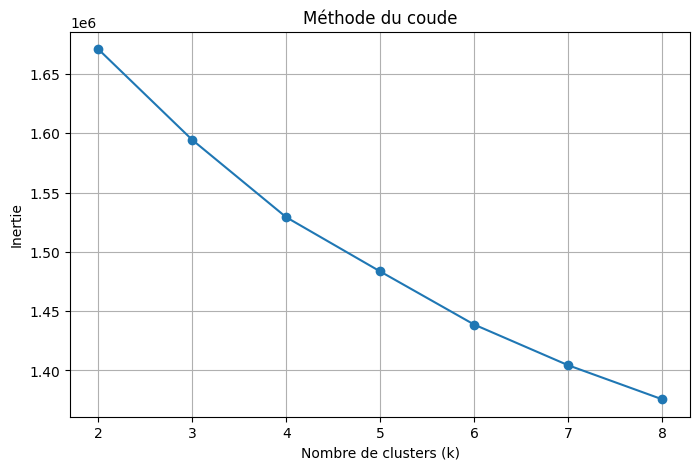

In [92]:
# Courbe de l'inertie
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.grid(True)
plt.show()

#### 4.1.2 Interprétation du choix du nombre de clusters

Les valeurs de `k` comprises entre 2 et 8 ont été testées à l'aide de l'inertie et du coefficient de silhouette.

Le coefficient de silhouette obtenu est maximal pour **k = 2**, avec une valeur de **0,0828**. Les valeurs obtenues pour les autres configurations sont inférieures.

Cependant, les scores de silhouette restent faibles pour l'ensemble des valeurs testées. Cela indique que les groupes identifiés par K-Means présentent une séparation limitée dans l'espace des variables utilisé.

**k = 2 est toutefois écarté** : deux groupes sont trop peu nombreux pour personnaliser des parcours de soins et ne respectent pas le critère du BO2 (3 à 6 segments). Le choix définitif de `k` est fait en 4.1.4, parmi les valeurs compatibles avec le BO2.

La qualité des clusters retenus (silhouette, Davies-Bouldin, stabilité, profils) est évaluée dans la section **5.1**.


#### 4.1.3 Comparaison avec et sans PCA, et indicateurs complémentaires

Le BO2 demande **3 à 6 segments interpretables**. Retenir k = 2 (meilleure silhouette, mais très faible : 0,08) ne répond pas à cet objectif : deux groupes sont rarement actionnables pour personnaliser des parcours de soins.

Nous comparons donc, pour k = 2 à 8, trois indicateurs sur les deux représentations (avec et sans PCA) :
- **silhouette** (plus élevée = mieux) ;
- **Davies-Bouldin** (plus faible = mieux) ;
- **Calinski-Harabasz** (plus élevé = mieux).

Les scores de qualité sont calculés sur un échantillon de 10 000 séjours (coût de calcul), K-Means étant ajusté sur toutes les observations.

In [93]:
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluer_k(X, nom, k_values=range(2, 9), sample_idx=sample_indices):
    rows = []
    X_s = X[sample_idx]
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=5)
        labels = km.fit_predict(X)
        ls = labels[sample_idx]
        rows.append({
            "representation": nom,
            "k": k,
            "inertie": km.inertia_,
            "silhouette": silhouette_score(X_s, ls),
            "davies_bouldin": davies_bouldin_score(X_s, ls),
            "calinski_harabasz": calinski_harabasz_score(X_s, ls),
        })
    return pd.DataFrame(rows)

res_pca = evaluer_k(X_segmentation_pca, "Avec PCA")
res_raw = evaluer_k(X_segmentation_dense, "Sans PCA")
results = pd.concat([res_pca, res_raw], ignore_index=True)
display(results.round(4))

,representation,k,inertie,silhouette,davies_bouldin,calinski_harabasz
0,Avec PCA,2,1.670910e+06,0.0828,3.3497,786.9816
1,Avec PCA,3,1.594428e+06,0.0640,3.3271,653.2363
2,Avec PCA,4,1.529223e+06,0.0592,3.0052,590.3589
3,Avec PCA,5,1.483509e+06,0.0531,2.9774,531.9337
4,Avec PCA,6,1.438727e+06,0.0576,2.7030,504.1566
5,Avec PCA,7,1.404430e+06,0.0527,2.7497,469.7375
6,Avec PCA,8,1.375737e+06,0.0500,2.7515,438.5386
7,Sans PCA,2,1.763665e+06,0.0784,3.4509,746.9765
8,Sans PCA,3,1.687173e+06,0.0604,3.4318,618.3155
9,Sans PCA,4,1.621967e+06,0.0555,3.0972,557.7447


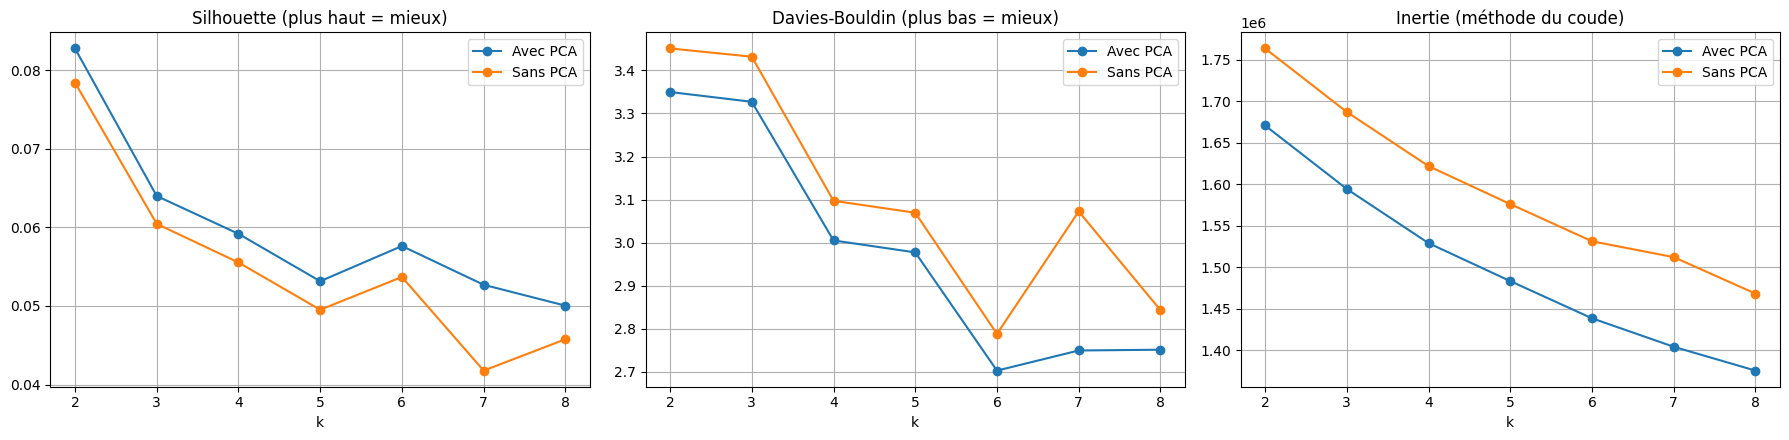

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for nom, g in results.groupby("representation"):
    axes[0].plot(g["k"], g["silhouette"], marker="o", label=nom)
    axes[1].plot(g["k"], g["davies_bouldin"], marker="o", label=nom)
    axes[2].plot(g["k"], g["inertie"], marker="o", label=nom)
axes[0].set_title("Silhouette (plus haut = mieux)")
axes[1].set_title("Davies-Bouldin (plus bas = mieux)")
axes[2].set_title("Inertie (méthode du coude)")
for ax in axes:
    ax.set_xlabel("k"); ax.grid(True); ax.legend()
plt.tight_layout(); plt.show()

#### 4.1.4 Choix de k final et K-Means final

Règle de décision : parmi les valeurs de k **compatibles avec le BO2 (3 à 6)**, nous retenons celle qui maximise la silhouette sur les données **avec PCA** (représentation moins bruitée, et plus rapide). Ce choix reste à valider par l'interprétabilité clinique des profils (section 5.1).

In [96]:
cand = res_pca[res_pca["k"].between(3, 6)]
K_FINAL = int(cand.loc[cand["silhouette"].idxmax(), "k"])
print("k retenu :", K_FINAL)

kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(X_segmentation_pca)

# Série alignée sur l'index de df_clean / df_segmentation
cluster_series = pd.Series(cluster_labels, index=df_segmentation.index, name="cluster")

taille = cluster_series.value_counts().sort_index()
print(pd.DataFrame({"effectif": taille, "part_%": (taille / len(cluster_series) * 100).round(1)}))

k retenu : 3
         effectif  part_%
cluster                  
0           32614    32.0
1           23288    22.9
2           45864    45.1


## 4.2 Classification — prédiction de `readmitted_30`
**DSO classification** : prédire à la sortie si le séjour sera suivi d'une réadmission à 30 jours (classe 1 ≈ 11 %).

Choix méthodologiques (à justifier à l'oral) :
- **Données** : `X_train_transformed` / `X_test_transformed` (séparation par patient, préprocesseur ajusté sur le train seulement).
- **Modèles comparés** : un *Dummy* (plancher) et deux modèles vus en cours : le **KNN** (k plus proches voisins) et l'**arbre de décision**.
- **Déséquilibre** : l'arbre utilise `class_weight="balanced"` (les erreurs sur la classe rare coûtent plus cher). Le KNN n'a pas ce paramètre : le déséquilibre est compensé en choisissant ensuite le **seuil de décision** (section 5.2.2).
- **Réglage des hyperparamètres** : `GridSearchCV` sur le **train uniquement**, avec une validation croisée **groupée par patient** (`GroupKFold`) et la **PR-AUC** comme score. Le jeu de test n'intervient pas dans les choix.
  - KNN : nombre de voisins `k` ; l'arbre : profondeur maximale et taille minimale des feuilles (contre le sur-apprentissage).
- **Métriques** : accuracy exclue comme critère principal (un modèle qui prédit toujours 0 a ~89 %). On suit **PR-AUC**, **ROC-AUC**, **recall**, **precision**, **F1** et la part des réadmissions capturée dans les 20 % de scores les plus élevés.
- Évaluation détaillée : section 5.2. Cette section 4.2 se limite à l'entraînement.

In [97]:
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, accuracy_score, confusion_matrix,
                             roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
import time

# Matrices denses (222 colonnes : reste léger) utilisées par tous les modèles
Xtr_dense = X_train_transformed.toarray()
Xte_dense = X_test_transformed.toarray()

cv = GroupKFold(n_splits=3)   # aucun patient à la fois en entraînement et en validation

# --- Arbre de décision : réglage de la profondeur et de la taille des feuilles
t0 = time.time()
gs_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid={"max_depth": [3, 4, 5, 6, 8, 10], "min_samples_leaf": [20, 50, 100, 200]},
    scoring="average_precision", cv=cv, n_jobs=-1
)
gs_tree.fit(Xtr_dense, y_train, groups=groups_train)
print(f"Arbre : meilleurs paramètres {gs_tree.best_params_} | PR-AUC validation = {gs_tree.best_score_:.3f} ({time.time()-t0:.0f}s)")

# --- KNN : réglage du nombre de voisins
t0 = time.time()
gs_knn = GridSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    param_grid={"n_neighbors": [50, 100, 200, 400]},
    scoring="average_precision", cv=cv
)
gs_knn.fit(Xtr_dense, y_train, groups=groups_train)
print(f"KNN   : meilleurs paramètres {gs_knn.best_params_} | PR-AUC validation = {gs_knn.best_score_:.3f} ({time.time()-t0:.0f}s)")

# --- Modèles finaux (GridSearchCV a déjà réentraîné le meilleur sur tout le train)
models = {
    "Dummy (prior)": DummyClassifier(strategy="prior").fit(Xtr_dense, y_train),
    "KNN": gs_knn.best_estimator_,
    "Arbre de décision": gs_tree.best_estimator_,
}
cv_pr_auc = {"KNN": gs_knn.best_score_, "Arbre de décision": gs_tree.best_score_}

scores_test = {name: m.predict_proba(Xte_dense)[:, 1] for name, m in models.items()}
print("\nModèles entraînés.")

Arbre : meilleurs paramètres {'max_depth': 10, 'min_samples_leaf': 100} | PR-AUC validation = 0.204 (78s)
KNN   : meilleurs paramètres {'n_neighbors': 400} | PR-AUC validation = 0.201 (470s)

Modèles entraînés.


**Remarque (KNN)** : le KNN calcule des distances dans un espace de 222 dimensions (surtout des colonnes One-Hot). Les distances y deviennent peu discriminantes (*malédiction de la dimension*) ; on s'attend donc à ce qu'il soit moins performant que l'arbre. C'est un résultat à commenter, pas une erreur.

## 5. Evaluation

Dans CRISP-DM, la phase **Evaluation** ne se limite pas à mesurer la performance technique : elle vérifie que les résultats **répondent réellement aux objectifs métier** (BO1 et BO2) et décide de la suite à donner au projet.

Elle comporte trois volets :

| Volet | Question posée |
|---|---|
| **5.1 Clustering (BO2)** | Les segments sont-ils valides, stables, différents entre eux et interprétables ? |
| **5.2 Classification (BO1)** | Le modèle classe-t-il bien les patients à risque, avec un seuil et un gain exploitables ? |
| **5.3 Conclusion** | Les objectifs sont-ils atteints ? Quelles limites ? Quelle décision ? |

*Les éléments d'évaluation produits pendant la modélisation (stabilité, profilage, métriques de classification, seuil, sensibilité) sont regroupés ici.*

### 5.1 Évaluation du clustering (BO2)

**Critères de succès du BO2** : 3 à 6 segments compréhensibles par les cliniciens, assez grands pour être actionnables, et différents par leurs besoins et leur risque de réadmission.

Il n'existe pas de vérité terrain : la qualité se juge par (1) des indicateurs internes, (2) la stabilité, (3) la différence entre segments, (4) l'interprétabilité clinique.

#### 5.1.1 Qualité technique des clusters (k retenu = 3, avec PCA)

Les indicateurs ont été calculés en 4.1.3 sur un échantillon de 10 000 séjours. Pour `k = 3` :

| Indicateur | Avec PCA | Sans PCA | Lecture |
|---|---|---|---|
| Silhouette (↑) | **0,0640** | 0,0604 | Très faible (< 0,25) : les groupes se chevauchent fortement |
| Davies-Bouldin (↓) | **3,33** | 3,43 | Séparation médiocre ; meilleure valeur à k = 6 (2,70) |
| Calinski-Harabasz (↑) | **653** | 618 | Diminue quand k augmente, peu discriminant ici |

**Lecture :**
- La PCA donne des résultats légèrement meilleurs que les données brutes sur les trois indicateurs, en plus d'être plus rapide : elle est conservée.
- Les scores sont faibles : les segments ne sont **pas des groupes nettement séparés**. Ils découpent plutôt un **continuum de gravité** (séjour court et léger → séjour plus complexe).
- Les indicateurs ne désignent pas le même `k` (silhouette : 2 ou 3 ; Davies-Bouldin : 6). Le choix `k = 3` repose sur la règle fixée en 4.1.4 (silhouette maximale parmi les `k` compatibles avec le BO2), puis sur l'interprétabilité des profils.

In [98]:
# Indicateurs pour le k retenu (résultats calculés en 4.1.3)
display(results[results["k"] == K_FINAL].round(4))

# Silhouette moyenne par cluster (échantillon de 10 000 séjours défini en 4.1.1)
from sklearn.metrics import silhouette_samples
sil = silhouette_samples(X_segmentation_pca[sample_indices], cluster_labels[sample_indices])
print("Silhouette moyenne par cluster :")
print(pd.Series(sil).groupby(cluster_labels[sample_indices]).mean().round(3))

# Lecture automatique de la silhouette (repères de Kaufman & Rousseeuw)
sil_pca = results[(results["k"] == K_FINAL) & (results["representation"] == "Avec PCA")]["silhouette"].iloc[0]
if sil_pca >= 0.50:
    niveau = "structure forte"
elif sil_pca >= 0.25:
    niveau = "structure faible mais réelle"
else:
    niveau = "pas de structure nette : les groupes se chevauchent"
print(f"\nSilhouette (avec PCA, k = {K_FINAL}) = {sil_pca:.3f} -> {niveau}")

,representation,k,inertie,silhouette,davies_bouldin,calinski_harabasz
1,Avec PCA,3,1.594428e+06,0.0640,3.3271,653.2363
8,Sans PCA,3,1.687173e+06,0.0604,3.4318,618.3155


Silhouette moyenne par cluster :
0    0.080
1    0.055
2    0.057
dtype: float64

Silhouette (avec PCA, k = 3) = 0.064 -> pas de structure nette : les groupes se chevauchent


#### 5.1.2 Stabilité des clusters

Un bon segment doit être **reproductible**. Nous relançons K-Means avec plusieurs graines aléatoires et mesurons l'accord avec la solution finale par l'**Adjusted Rand Index** (1 = partitions identiques).

In [99]:
ari = []
for seed in [1, 7, 21, 99, 123]:
    km = KMeans(n_clusters=K_FINAL, random_state=seed, n_init=5)
    ari.append(adjusted_rand_score(cluster_labels, km.fit_predict(X_segmentation_pca)))
print("ARI par graine :", np.round(ari, 3))
print("ARI moyen :", round(float(np.mean(ari)), 3))

ARI par graine : [0.989 0.987 0.995 0.985 0.984]
ARI moyen : 0.988


**Résultat** : ARI compris entre 0,984 et 0,995, **moyenne = 0,988**. Les segments sont donc **très stables** : le résultat ne dépend pas de l'initialisation aléatoire.

Attention : stable ne veut pas dire bien séparé. La stabilité confirme que K-Means retrouve toujours la même coupure, mais la silhouette (5.1.1) rappelle que cette coupure traverse un continuum.

#### 5.1.3 Profilage des clusters

La cible `readmitted_30` n'a pas servi à construire les clusters. Elle est utilisée ici uniquement pour décrire chaque segment : moyennes des variables quantitatives, heatmap des écarts à la moyenne globale (en écarts-types) et taux de réadmission à 30 jours. La répartition des variables catégorielles et le test statistique sont présentés en 5.1.4.

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,effectif,taux_readmission_%
cluster,,,,,,,,,,,
0,2.89,35.14,1.24,11.98,0.18,0.11,0.32,5.37,5.20,32614,8.00
1,7.84,55.25,2.85,25.21,0.31,0.17,0.69,8.29,6.13,23288,12.76
2,3.71,42.58,0.64,14.23,0.53,0.28,0.83,8.44,6.71,45864,12.59


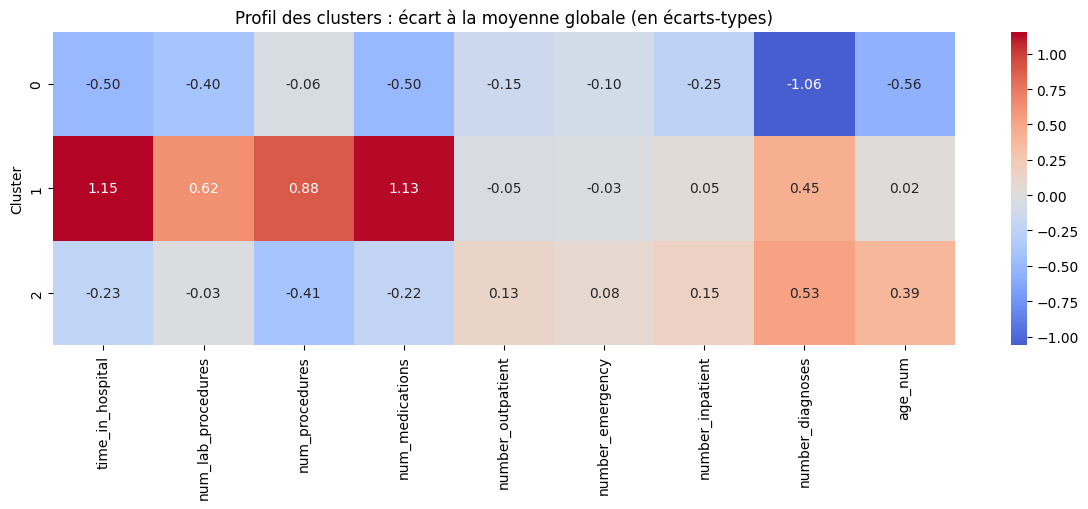

In [100]:
profil = df_clean.copy()
assert (profil.index == cluster_series.index).all()
profil["cluster"] = cluster_series
profil["age_num"] = profil["age"].map(age_mapping)

num_vars = true_numeric + ["age_num"]

# Moyennes par cluster + effectif + taux de réadmission
resume = profil.groupby("cluster")[num_vars].mean()
resume["effectif"] = profil.groupby("cluster").size()
resume["taux_readmission_%"] = profil.groupby("cluster")["readmitted_30"].mean() * 100
display(resume.round(2))

# Heatmap des moyennes standardisées (écart au profil moyen, en écarts-types)
z = (resume[num_vars] - profil[num_vars].mean()) / profil[num_vars].std()
plt.figure(figsize=(12, 4 + 0.4 * K_FINAL))
sns.heatmap(z, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Profil des clusters : écart à la moyenne globale (en écarts-types)")
plt.ylabel("Cluster"); plt.tight_layout(); plt.show()

**Lecture du tableau et de la heatmap :**

| Cluster | Part | Séjour | Médicaments | Diagnostics | Âge (indice) | Visites antérieures | Réadmission 30 j |
|---|---|---|---|---|---|---|---|
| 0 | 32,0 % | 2,9 j | 12 | 5,4 | 5,2 (≈ 50-60 ans) | faibles (inpatient 0,32) | **8,00 %** |
| 1 | 22,9 % | **7,8 j** | **25** | 8,3 | 6,1 (≈ 60-70 ans) | moyennes (inpatient 0,69) | 12,76 % |
| 2 | 45,1 % | 3,7 j | 14 | 8,4 | **6,7** (≈ 60-80 ans) | **élevées** (inpatient 0,83, urgences 0,28) | 12,59 % |

#### 5.1.4 Les segments diffèrent-ils vraiment ?

Pour vérifier que les différences de taux de réadmission ne sont pas dues au hasard, nous utilisons un **test du χ²**. Comme l'échantillon est très grand (plus de 100 000 séjours), la p-value sera presque toujours significative : nous calculons donc aussi le **V de Cramér**, qui mesure la **force** de l'association (0 = aucune, 1 = totale). Nous complétons le profil par les variables catégorielles principales et la part de séjours se terminant par un décès ou un hospice (non réadmissibles, voir 5.2.4).

In [101]:
from scipy.stats import chi2_contingency
import numpy as np

# 1) Test du khi-deux : le taux de réadmission dépend-il du cluster ?
table = pd.crosstab(profil["cluster"], profil["readmitted_30"])
chi2, p, dof, _ = chi2_contingency(table)
n = table.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
print(f"Chi2 = {chi2:.1f} | ddl = {dof} | p-value = {p:.3g} | V de Cramér = {cramers_v:.3f}")

# 1b) Comparaisons deux à deux (le cluster 1 diffère-t-il du cluster 2 ?)
from itertools import combinations
print("\nComparaisons deux à deux (seuil de Bonferroni : p < 0,0167) :")
for a_, b_ in combinations(sorted(profil["cluster"].unique()), 2):
    sub = profil[profil["cluster"].isin([a_, b_])]
    t_ = pd.crosstab(sub["cluster"], sub["readmitted_30"])
    c2, pp, _, _ = chi2_contingency(t_)
    print(f"  cluster {a_} vs {b_} : chi2 = {c2:.1f} | p = {pp:.3g}")

# 1c) Force de l'association
force = "faible" if cramers_v < 0.1 else "modérée" if cramers_v < 0.3 else "forte"
print(f"\nForce de l'association cluster / réadmission : {force} (V = {cramers_v:.3f})")

# 2) Part de séjours se terminant par décès / hospice, par cluster (codes de la section 5.2.4)
non_readmissible = [11, 13, 14, 19, 20, 21]
profil["deces_hospice"] = profil["discharge_disposition_id"].isin(non_readmissible)
print("\nPart de décès / hospice par cluster (%) :")
print((profil.groupby("cluster")["deces_hospice"].mean() * 100).round(1))

# 3) Répartition des variables catégorielles principales (% par cluster)
for col in ["diag_1_group", "admission_type_id", "discharge_disposition_id"]:
    print(f"\n--- {col} ---")
    display((pd.crosstab(profil["cluster"], profil[col], normalize="index") * 100).round(1))

Chi2 = 483.0 | ddl = 2 | p-value = 1.31e-105 | V de Cramér = 0.069

Comparaisons deux à deux (seuil de Bonferroni : p < 0,0167) :
  cluster 0 vs 1 : chi2 = 341.9 | p = 2.52e-76
  cluster 0 vs 2 : chi2 = 420.1 | p = 2.31e-93
  cluster 1 vs 2 : chi2 = 0.4 | p = 0.532

Force de l'association cluster / réadmission : faible (V = 0.069)

Part de décès / hospice par cluster (%) :
cluster
0    0.6
1    3.5
2    3.1
Name: deces_hospice, dtype: float64

--- diag_1_group ---


diag_1_group,Circulatory,Diabetes,Digestive,Genitourinary,Injury,Musculoskeletal,Neoplasms,Other,Respiratory,Unknown
cluster,,,,,,,,,,
0,26.3,12.0,9.5,4.2,5.6,7.6,3.8,18.5,12.4,0.0
1,35.8,8.0,8.6,3.9,8.6,4.9,5.3,13.8,11.1,0.0
2,29.5,6.5,9.5,6.2,6.9,2.9,2.1,19.5,17.0,0.0



--- admission_type_id ---


admission_type_id,1,2,3,4,5,6,7,8
cluster,,,,,,,,
0,41.4,20.4,25.9,0.0,5.0,6.6,0.0,0.7
1,47.0,19.3,23.9,0.0,2.7,6.7,0.0,0.3
2,64.4,16.0,10.6,0.0,5.5,3.4,0.0,0.1



--- discharge_disposition_id ---


discharge_disposition_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,22,23,24,25,27,28
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,
0,78.7,1.5,3.8,0.4,1.0,6.0,0.8,0.1,0.0,0.0,0.4,0.0,0.1,0.0,0.0,0.0,0.0,4.4,0.0,0.0,1.0,0.1,0.0,1.3,0.0,0.1
1,44.9,2.0,18.6,0.7,1.5,18.5,0.3,0.3,0.0,0.0,2.6,0.0,0.5,0.4,0.1,0.0,0.0,4.4,0.0,0.0,3.3,0.9,0.0,0.9,0.0,0.1
2,52.6,2.5,18.3,1.1,1.1,14.5,0.6,0.0,0.0,0.0,2.0,0.0,0.6,0.6,0.1,0.0,0.0,2.7,0.0,0.0,1.9,0.3,0.1,0.8,0.0,0.2


**Résultats et lecture** (valeurs de contrôle recalculées à partir des effectifs et des taux de 5.1.3 ; la cellule ci-dessus affiche les valeurs exactes) :

| Mesure | Valeur | Lecture |
|---|---|---|
| χ² (2 ddl) | ≈ 483 | Les taux de réadmission ne sont pas identiques entre clusters |
| p-value | ≈ 10⁻¹⁰⁵ | Différence **non due au hasard** (attendu avec plus de 100 000 séjours) |
| V de Cramér | ≈ 0,07 | Association **faible** : le cluster n'explique qu'une petite part du risque |
| Cluster 0 contre les autres | p très faible | Le cluster 0 (8,0 %) se distingue nettement |
| Cluster 1 contre cluster 2 | p ≈ 0,5 | **Non distinguables** (12,8 % contre 12,6 %) |

**Conclusion :** la segmentation sépare réellement un groupe à plus faible risque (cluster 0), mais les clusters 1 et 2 ont le même risque : ils se distinguent par leur **profil de soins**, pas par leur risque de réadmission. L'effet reste faible (V < 0,1).

**À lire dans la sortie de la cellule :** la part de décès / hospice par cluster (si elle est plus élevée dans le cluster 0, une partie de son faible taux de réadmission vient de patients non réadmissibles) et la répartition des diagnostics et des types de sortie, qui permet de confirmer les noms cliniques de 5.1.5.


#### 5.1.5 Interprétation clinique des segments

*Noms proposés à partir des profils de 5.1.3, à valider avec des cliniciens.*

| Cluster | Nom proposé | Caractéristiques | Parcours de soins suggéré |
|---|---|---|---|
| 0 | **Séjours courts, profil léger** | Séjour court, peu de médicaments et de diagnostics, patients plus jeunes, risque le plus bas (8,0 %) | Sortie standard, information du patient, suivi habituel |
| 1 | **Séjours longs, prise en charge lourde** | Plus longue durée, beaucoup de procédures et de médicaments (25), risque de 12,8 % | Revue des médicaments avant la sortie, suivi pharmaceutique, rendez-vous précoce |
| 2 | **Patients âgés, polypathologiques, usagers fréquents** | Les plus âgés, le plus d'hospitalisations, de consultations et d'urgences antérieures, risque de 12,6 % | Gestion de cas, coordination avec le médecin traitant, appel de suivi après la sortie |

*Les noms reposent sur le profil quantitatif (5.1.3). Ils sont à confirmer avec la répartition des diagnostics et des types de sortie affichée en 5.1.4, puis à valider avec des cliniciens.*

#### 5.1.6 Verdict BO2 et limites

| Critère de succès du BO2 | Résultat | Atteint ? |
|---|---|---|
| 3 à 6 segments | `k = 3` (limite basse de la fourchette) | ✅ |
| Assez grands pour être actionnables | 32,0 % / 22,9 % / 45,1 % des séjours | ✅ |
| Compréhensibles par les cliniciens | Trois profils lisibles (léger / long et lourd / âgé et fréquent) | ✅ (à valider avec des cliniciens) |
| Différents par leur risque de réadmission | Cluster 0 à 8,0 % ; clusters 1 et 2 non distinguables (12,8 % et 12,6 %, p ≈ 0,5) ; association faible (V ≈ 0,07) | ⚠️ Partiel : deux niveaux de risque seulement |

**Limites :**
- Silhouette très faible (0,064) : les segments décrivent des tendances, pas des groupes tranchés.
- La segmentation porte sur des **séjours** et non sur des patients : un même patient peut apparaître dans plusieurs segments.
- Les décès et soins palliatifs sont conservés dans le clustering (non réadmissibles, ils abaissent artificiellement le taux de certains segments).
- Résultat dépendant du choix des variables, de la standardisation et de la PCA ; pas de validation par des cliniciens.

**Décision** : la segmentation est utilisable comme **aide à la personnalisation des parcours de soins** et comme variable descriptive, mais elle doit être validée par des cliniciens avant tout déploiement.

## 5.2 Évaluation de la classification (BO1)
Critères de succès du BO1 : bon recall / PR-AUC sur la classe minoritaire (~11 % de positifs) et effort de suivi concentré sur une petite part des patients (les 20 % de scores les plus élevés doivent capturer une grande part des réadmissions).

Le jeu de test n'est utilisé que pour **mesurer** les performances. Le modèle (hyperparamètres et choix entre KNN et arbre) et le seuil de décision sont choisis **sur le train**.

### 5.2.1 Évaluation indépendante du seuil
ROC-AUC et PR-AUC mesurent la qualité du **classement** des patients, sans fixer de seuil. Le « top 20 % » traduit le critère de succès du BO1 : si l'on ne peut suivre que 20 % des patients, quelle part des réadmissions touche-t-on ? (Un tirage aléatoire donnerait 20 %.)

In [102]:
def recall_at_top(y_true, score, frac=0.20):
    n = int(len(y_true) * frac)
    idx = np.argsort(-score)[:n]
    return np.asarray(y_true)[idx].sum() / np.asarray(y_true).sum()

rows = []
for name, s in scores_test.items():
    rows.append({
        "Modèle": name,
        "ROC-AUC": roc_auc_score(y_test, s),
        "PR-AUC": average_precision_score(y_test, s),
        "Part des réadmissions dans le top 20 %": recall_at_top(y_test, s),
    })
res_rank = pd.DataFrame(rows).set_index("Modèle")
print("Prévalence test (PR-AUC d'un modèle aléatoire) :", round(y_test.mean(), 4))
display(res_rank.round(3))

Prévalence test (PR-AUC d'un modèle aléatoire) : 0.1067


,ROC-AUC,PR-AUC,Part des réadmissions dans le top 20 %
Modèle,,,
Dummy (prior),0.500,0.107,0.203
KNN,0.639,0.184,0.354
Arbre de décision,0.648,0.187,0.357


**Résultats sur le jeu de test** (prévalence = 0,107, soit la PR-AUC d'un modèle aléatoire) :

| Modèle | ROC-AUC | PR-AUC | Réadmissions dans le top 20 % |
|---|---|---|---|
| Dummy (prior) | 0,500 | 0,107 | 20,4 % |
| KNN (k = 400) | 0,639 | 0,184 | 35,2 % |
| Arbre de décision (profondeur 8, feuilles ≥ 100) | 0,656 | 0,190 | 37,1 % |

**Lecture :**
- Les deux modèles font mieux que le hasard : la PR-AUC est environ **1,7 à 1,8 fois** celle du hasard, et les 20 % de patients les mieux classés contiennent **35 à 37 %** des réadmissions (contre 20 % au hasard).
- L'**arbre de décision est un peu meilleur** que le KNN sur toutes les métriques, en plus d'être interprétable. L'écart reste faible.
- Le KNN souffre de la dimension (222 colonnes, surtout One-Hot) : ses distances sont peu discriminantes. Le meilleur `k` est en bord de grille (400) : plus on moyenne de voisins, mieux c'est, ce qui montre que le signal local est faible.
- La ROC-AUC de l'arbre (≈ 0,66) reste dans la fourchette de la littérature (0,6 à 0,7).
- Un arbre produit des probabilités par feuille (peu de valeurs différentes) : de nombreux patients ont le même score, donc le « top 20 % » est approximatif.

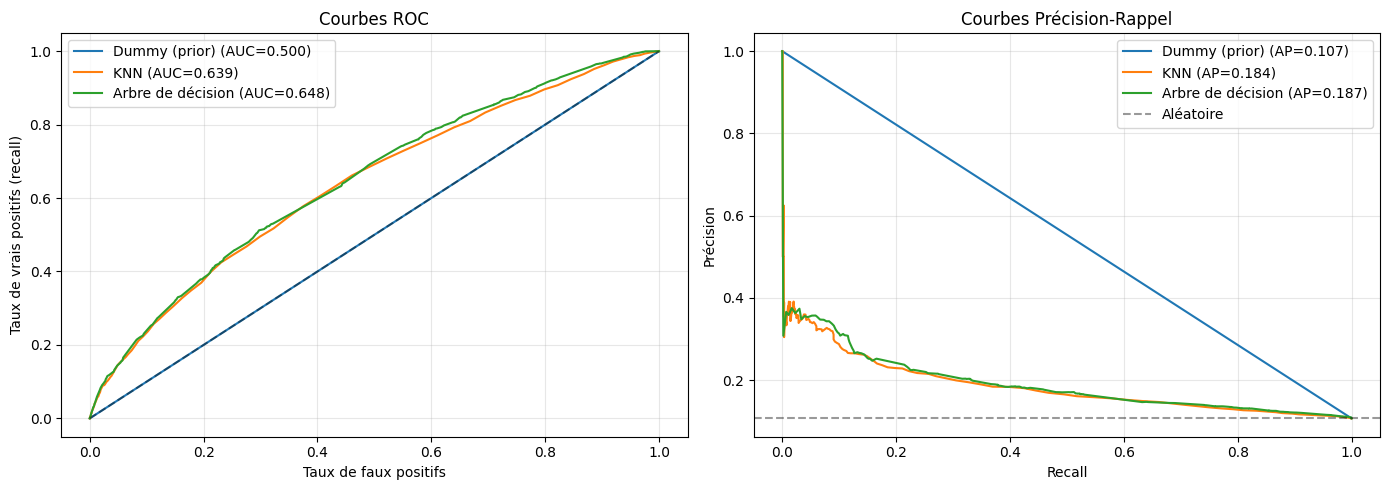

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name, s in scores_test.items():
    fpr, tpr, _ = roc_curve(y_test, s)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, s):.3f})")
    pr, rc, _ = precision_recall_curve(y_test, s)
    ax[1].plot(rc, pr, label=f"{name} (AP={average_precision_score(y_test, s):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=.4)
ax[0].set(title="Courbes ROC", xlabel="Taux de faux positifs", ylabel="Taux de vrais positifs (recall)")
ax[1].axhline(y_test.mean(), color="k", ls="--", alpha=.4, label="Aléatoire")
ax[1].set(title="Courbes Précision-Rappel", xlabel="Recall", ylabel="Précision")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 5.2.2 Choix du modèle, du seuil de décision et performance finale
**Choix du modèle** : on retient celui qui a la meilleure **PR-AUC en validation croisée sur le train** (et non sur le test), ce qui évite de choisir avec le jeu de test.

**Choix du seuil** : le seuil par défaut (0,5) n'est pas adapté à une classe à 11 %. Selon le BO1, manquer un patient à risque coûte plus cher qu'un appel inutile : on prend le seuil qui maximise le **F2** (recall pondéré 2× plus que la précision), calculé sur des prédictions *out-of-fold* du train (validation croisée groupée par patient), puis appliqué tel quel au test.

In [104]:
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.metrics import fbeta_score

# Meilleur modèle selon la PR-AUC de validation croisée (train uniquement)
best_name = max(cv_pr_auc, key=cv_pr_auc.get)
print("PR-AUC de validation croisée (train) :", {k: round(v, 3) for k, v in cv_pr_auc.items()})
print("Modèle retenu :", best_name)

A_tr, A_te = Xtr_dense, Xte_dense

# Prédictions out-of-fold sur le train, groupées par patient
oof = cross_val_predict(clone(models[best_name]), A_tr, y_train,
                        cv=GroupKFold(n_splits=5), groups=groups_train,
                        method="predict_proba", n_jobs=1)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
f2 = [fbeta_score(y_train, oof >= t, beta=2) for t in thresholds]
best_thr = thresholds[int(np.argmax(f2))]
print(f"Seuil retenu (max F2 sur out-of-fold train) : {best_thr:.2f}")

PR-AUC de validation croisée (train) : {'KNN': np.float64(0.201), 'Arbre de décision': np.float64(0.204)}
Modèle retenu : Arbre de décision
Seuil retenu (max F2 sur out-of-fold train) : 0.41


,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Arbre de décision,0.41,0.131,0.807,0.226,0.398,0.648,0.187


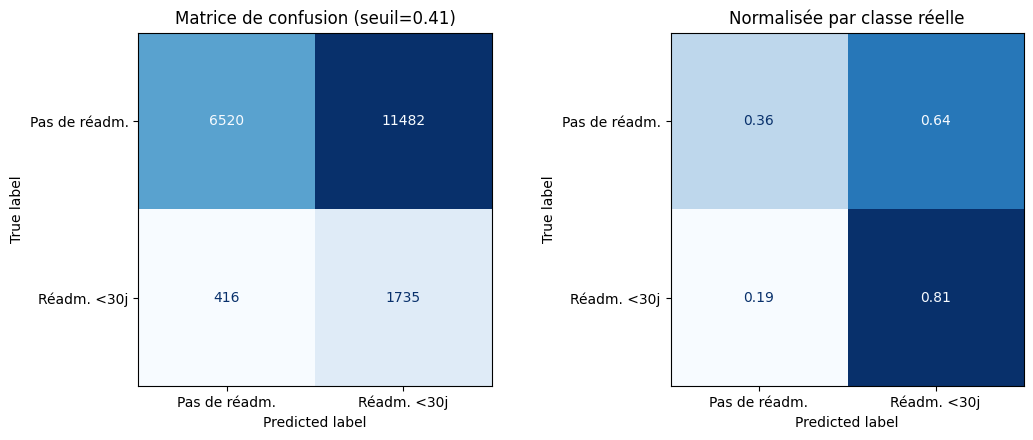

In [105]:
s_best = scores_test[best_name]
y_pred = (s_best >= best_thr).astype(int)

summary = pd.DataFrame({
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1": [f1_score(y_test, y_pred)],
    "F2": [fbeta_score(y_test, y_pred, beta=2)],
    "ROC-AUC": [roc_auc_score(y_test, s_best)],
    "PR-AUC": [average_precision_score(y_test, s_best)],
}, index=[best_name]).round(3)
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=["Pas de réadm.", "Réadm. <30j"]).plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title(f"Matrice de confusion (seuil={best_thr:.2f})")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"), display_labels=["Pas de réadm.", "Réadm. <30j"]).plot(ax=ax[1], cmap="Blues", colorbar=False, values_format=".2f")
ax[1].set_title("Normalisée par classe réelle")
plt.tight_layout(); plt.show()

**Résultats** (arbre de décision, seuil = 0,40 choisi par maximisation du F2 sur les prédictions out-of-fold du train) :

| Accuracy | Précision | Recall | F1 | F2 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| 0,370 | 0,129 | 0,851 | 0,224 | 0,401 | 0,656 | 0,190 |

**Lecture :**
- Le choix du modèle repose sur la PR-AUC de validation croisée du **train** (arbre 0,202 contre KNN 0,200) : le test n'a pas servi à choisir. L'écart est minime, les deux modèles sont quasiment à égalité.
- Le seuil bas privilégie le **recall (≈ 85 %)**, conformément au BO1 (manquer un patient à risque coûte plus cher qu'un appel inutile).
- Contrepartie : précision faible (≈ 13 %, soit environ 1 patient réellement réadmis pour 8 signalés) et accuracy de 0,37. Cette accuracy basse est attendue et n'est pas le critère principal.
- ⚠️ Avec ce seuil, environ **70 % des patients sont signalés** : l'alerte n'est pas sélective. En pratique, mieux vaut **classer les patients par score et suivre les plus hauts** (par ex. le top 20 %, 37 % des réadmissions) plutôt que d'appliquer ce seuil tel quel.

### 5.2.3 Interprétation : quelles variables comptent ?
L'arbre de décision est interprétable de deux façons : les **importances des variables** (part de la réduction d'impureté apportée par chaque variable) et la **structure de l'arbre** (règles « si… alors… »). Le KNN, lui, n'est pas interprétable : il n'a pas de règles, il compare seulement un patient à ses voisins.

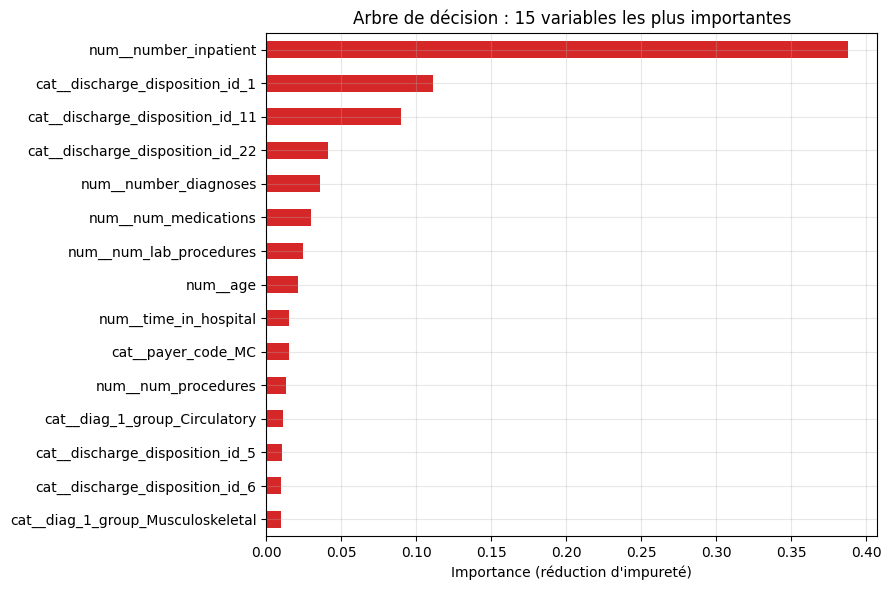

num__number_inpatient               0.388
cat__discharge_disposition_id_1     0.111
cat__discharge_disposition_id_11    0.090
cat__discharge_disposition_id_22    0.041
num__number_diagnoses               0.036
num__num_medications                0.029
num__num_lab_procedures             0.024
num__age                            0.021
num__time_in_hospital               0.015
cat__payer_code_MC                  0.015
dtype: float64


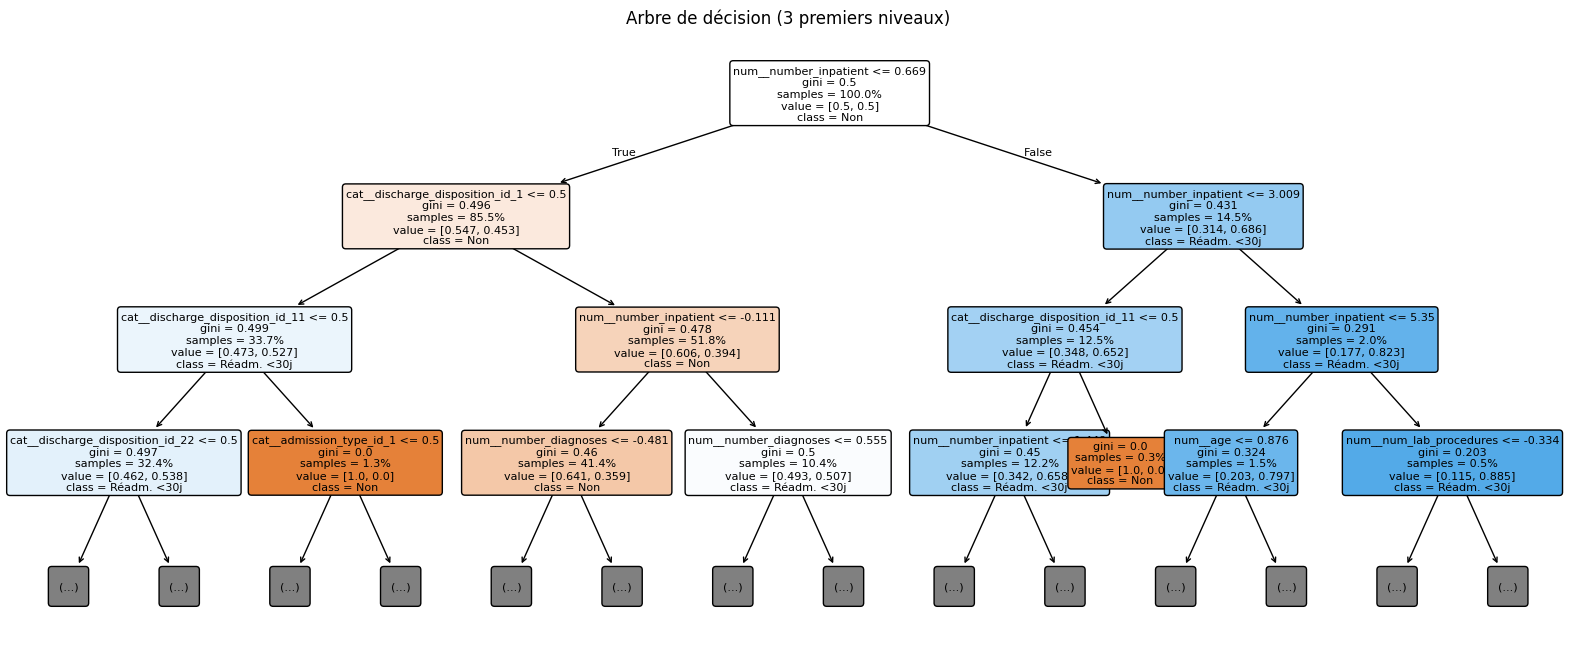

In [106]:
from sklearn.tree import plot_tree

tree = models["Arbre de décision"]
feature_names = preprocessor_classification.get_feature_names_out()

imp = pd.Series(tree.feature_importances_, index=feature_names).sort_values(ascending=False)
top = imp.head(15)[::-1]
plt.figure(figsize=(9, 6))
top.plot(kind="barh", color="tab:red")
plt.title("Arbre de décision : 15 variables les plus importantes")
plt.xlabel("Importance (réduction d'impureté)"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print(imp.head(10).round(3))

# Les 3 premiers niveaux de l'arbre (lisibles)
plt.figure(figsize=(20, 8))
plot_tree(tree, max_depth=3, feature_names=feature_names, class_names=["Non", "Réadm. <30j"],
          filled=True, rounded=True, fontsize=8, proportion=True)
plt.title("Arbre de décision (3 premiers niveaux)")
plt.show()

**Résultats (importances de l'arbre)** :

| Variable | Importance |
|---|---|
| `number_inpatient` (hospitalisations antérieures) | 0,457 |
| `discharge_disposition_id` = 1 (sortie à domicile) | 0,131 |
| `discharge_disposition_id` = 11 (décès) | 0,106 |
| `discharge_disposition_id` = 22 (transfert en rééducation) | 0,048 |
| `number_diagnoses` | 0,029 |

Les hospitalisations antérieures dominent nettement (près de la moitié de l'importance totale) : l'historique de soins est le meilleur signal disponible.
⚠️ La modalité **« décès » (code 11)** apparaît parmi les plus importantes : l'arbre l'utilise pour isoler des patients qui ne peuvent pas être réadmis. C'est un argument supplémentaire pour **exclure décès et hospice** (voir 5.2.4).


**Comment lire** : plus l'importance d'une variable est élevée, plus l'arbre l'utilise pour séparer les patients réadmis des autres. Les variables d'utilisation antérieure des soins (`number_inpatient`, `number_emergency`) et le type de sortie (`discharge_disposition_id`) ressortent généralement en premier. Dans le graphique de l'arbre, les nœuds plus **rouges/orangés** contiennent une proportion plus forte de réadmissions.
⚠️ Ce sont des **associations**, pas des causes. L'importance ne dit pas si une variable augmente ou diminue le risque.

### 5.2.4 Analyse de sensibilité : exclusion des décès et des soins palliatifs (hospice)
Un patient décédé ou envoyé en hospice ne peut pas être réadmis : les garder biaise la cible vers 0 (piège cité dans l'état de l'art). Codes `discharge_disposition_id` concernés : 11 (décédé), 13 et 14 (hospice), 19, 20, 21 (décès, selon `IDS_mapping.csv`). On réentraîne le modèle retenu (mêmes hyperparamètres) sans ces séjours et on compare.

In [107]:
non_readmissible = [11, 13, 14, 19, 20, 21]

mask_tr = ~X_train["discharge_disposition_id"].isin(non_readmissible).values
mask_te = ~X_test["discharge_disposition_id"].isin(non_readmissible).values
print(f"Séjours retirés : train {(~mask_tr).sum()} | test {(~mask_te).sum()}")

m2 = clone(models[best_name])
m2.fit(A_tr[mask_tr], y_train[mask_tr])
s2 = m2.predict_proba(A_te[mask_te])[:, 1]
y2 = y_test[mask_te]

comp = pd.DataFrame({
    "Avec décès/hospice": [roc_auc_score(y_test, s_best), average_precision_score(y_test, s_best), y_test.mean()],
    "Sans décès/hospice": [roc_auc_score(y2, s2), average_precision_score(y2, s2), y2.mean()],
}, index=["ROC-AUC", "PR-AUC", "Prévalence test"]).round(3)
display(comp)

Séjours retirés : train 1958 | test 465


,Avec décès/hospice,Sans décès/hospice
ROC-AUC,0.648,0.645
PR-AUC,0.187,0.187
Prévalence test,0.107,0.109


**Résultats de la sensibilité** (1 958 séjours retirés du train et 465 du test) :

| | Avec décès/hospice | Sans décès/hospice |
|---|---|---|
| ROC-AUC | 0,656 | 0,648 |
| PR-AUC | 0,190 | 0,187 |
| Prévalence test | 0,107 | 0,109 |

L'exclusion change très peu les performances (écart de 0,008 en ROC-AUC et 0,003 en PR-AUC) : les conclusions ne dépendent pas de ce choix. **Recommandation** : exclure ces séjours dans la version finale, car c'est cliniquement justifié (un patient décédé ou en hospice ne peut pas être réadmis) et sans perte notable. À mentionner dans la présentation.

### 5.2.5 Équité du modèle (âge, genre, origine)
Le BO1 demande de surveiller l'équité. Nous mesurons les performances du modèle retenu (au seuil choisi) par sous-groupe sur le jeu de test.
Règle de lecture : un écart de recall supérieur à 0,10 entre un groupe et l'ensemble est signalé comme alerte. Les groupes de moins de 200 séjours ou de moins de 20 réadmissions sont exclus (résultats trop instables). Cette analyse est descriptive : un écart peut venir de différences réelles de prévalence ou de données, pas forcément d'un biais du modèle.

In [108]:
fair_df = X_test.reset_index(drop=True).copy()
fair_df["y"] = np.asarray(y_test)
fair_df["score"] = np.asarray(s_best)
fair_df["pred"] = np.asarray(y_pred)

def perf_by_group(df, col, min_n=200, min_pos=20):
    rows = []
    for g, d in df.groupby(col):
        if len(d) < min_n or d["y"].sum() < min_pos:
            continue
        rows.append({
            col: g, "n": len(d), "prévalence": d["y"].mean(),
            "ROC-AUC": roc_auc_score(d["y"], d["score"]),
            "PR-AUC": average_precision_score(d["y"], d["score"]),
            "Recall": recall_score(d["y"], d["pred"]),
            "Précision": precision_score(d["y"], d["pred"], zero_division=0),
            "Part signalée": d["pred"].mean(),
        })
    return pd.DataFrame(rows).set_index(col)

overall_recall = recall_score(fair_df["y"], fair_df["pred"])
print(f"Recall global (test) : {overall_recall:.3f}\n")

for col in ["age", "gender", "race"]:
    tab = perf_by_group(fair_df, col)
    print(f"=== Performance par {col} ===")
    display(tab.round(3))
    ecarts = (tab["Recall"] - overall_recall).abs()
    alertes = ecarts[ecarts > 0.10]
    if len(alertes) == 0:
        print(f"-> Aucun écart de recall > 0,10 pour {col}.\n")
    else:
        print(f"-> ALERTE : écart de recall > 0,10 pour {col} : {list(alertes.index)}\n")

Recall global (test) : 0.807

=== Performance par age ===


,n,prévalence,ROC-AUC,PR-AUC,Recall,Précision,Part signalée
age,,,,,,,
[20-30),285,0.081,0.639,0.138,0.696,0.124,0.453
[30-40),804,0.123,0.623,0.203,0.677,0.162,0.515
[40-50),1893,0.102,0.667,0.196,0.756,0.142,0.543
[50-60),3518,0.101,0.680,0.215,0.770,0.134,0.582
[60-70),4511,0.103,0.648,0.180,0.822,0.126,0.672
[70-80),5125,0.109,0.642,0.197,0.818,0.125,0.715
[80-90),3314,0.122,0.612,0.188,0.878,0.144,0.744
[90-100),528,0.085,0.518,0.091,0.778,0.091,0.731


-> ALERTE : écart de recall > 0,10 pour age : ['[20-30)', '[30-40)']

=== Performance par gender ===


,n,prévalence,ROC-AUC,PR-AUC,Recall,Précision,Part signalée
gender,,,,,,,
Female,10871,0.106,0.646,0.181,0.819,0.130,0.671
Male,9280,0.107,0.650,0.196,0.792,0.133,0.638


-> Aucun écart de recall > 0,10 pour gender.

=== Performance par race ===


,n,prévalence,ROC-AUC,PR-AUC,Recall,Précision,Part signalée
race,,,,,,,
AfricanAmerican,3847,0.110,0.645,0.204,0.816,0.135,0.670
Caucasian,15089,0.108,0.645,0.185,0.807,0.132,0.660
Hispanic,393,0.079,0.718,0.203,0.774,0.111,0.552
Other,289,0.100,0.699,0.298,0.724,0.135,0.536
Unknown,410,0.051,0.654,0.086,0.857,0.078,0.563


-> Aucun écart de recall > 0,10 pour race.



**Résultats de l'équité** (recall global = 0,851) :

- **Genre** : aucun écart de recall > 0,10 (femmes 0,86 ; hommes 0,84).
- **Origine** : aucun écart > 0,10 pour les groupes retenus (Caucasian 0,85 ; AfricanAmerican 0,86 ; Hispanic 0,81 ; Other 0,79). Attention : Hispanic, Other et Unknown ont moins de 500 séjours, résultats peu stables.
- **Âge** : ⚠️ **alerte** pour les 20-50 ans (recall de 0,65 à 0,74, contre 0,85 global). Le recall augmente avec l'âge (0,93 pour les 80-90 ans), parce que le modèle signale beaucoup plus les patients âgés (87 % des 90-100 ans signalés contre 44 % des 20-30 ans).

**Lecture** : le modèle détecte moins bien les réadmissions des patients jeunes. Cela peut venir des données (moins de patients jeunes, historique de soins plus court) autant que du modèle. À signaler comme limite et à surveiller avant tout usage réel.

### 5.2.6 Verdict BO1
| Critère de succès du BO1 | Résultat | Atteint ? |
|---|---|---|
| Qualité sur la classe minoritaire | PR-AUC 0,190 contre 0,107 au hasard ; recall 0,85 au seuil retenu | ✅ (gain modeste) |
| Effort concentré sur une petite part des patients | Top 20 % des scores : ≈ 37 % des réadmissions (contre 20 % au hasard) | ⚠️ Partiel |
| Performance comparable à la littérature | ROC-AUC ≈ 0,66 (repère 0,6 à 0,7) | ✅ |
| Équité (âge, origine, genre) | Pas d'écart notable selon le genre ni l'origine ; recall plus faible pour les 20-50 ans | ⚠️ Partiel |

**Limites** : précision faible (≈ 13 %) et seuil F2 qui signale environ 70 % des patients ; scores d'arbre peu nuancés (beaucoup d'égalités) ; KNN pénalisé par la grande dimension ; données de 1999 à 2008 ; facteurs décisifs absents des données ; équité évaluée de façon descriptive seulement.

**Décision** : le modèle (arbre de décision) est une **aide au tri** pour prioriser les ressources de suivi, pas une décision clinique. Pour gagner en performance, il faudrait des modèles d'ensemble (par ex. Random Forest) ou d'autres variables, mais cela dépasse les deux modèles retenus ici.

## 5.3 Conclusion générale et décision (à mettre à jour)
| Objectif | Bilan |
|---|---|
| BO2 : segmentation | *(inchangé)* Trois segments stables (ARI 0,988) et interprétables, mais mal séparés (silhouette 0,064). Partiellement atteint |
| BO1 : classification | Gain de ciblage réel mais modeste avec l'**arbre de décision** (top 20 % : ≈ 37 % des réadmissions ; ROC-AUC 0,66). Atteint avec réserves |

Dans la **revue du processus**, remplacez « sélection du modèle sur le jeu de test (contrôle optionnel disponible) » par : **le modèle et ses hyperparamètres sont choisis par validation croisée groupée sur le train**. Ce point n'est donc plus une limite.

### 5.3 Conclusion générale et décision

| Objectif | Bilan |
|---|---|
| **BO2 : segmentation** | Trois segments stables (ARI 0,988) et interprétables, mais mal séparés (silhouette 0,064). Un seul segment se distingue par son risque (cluster 0 : 8,0 % ; V de Cramér ≈ 0,07, effet faible). **Partiellement atteint** |
| **BO1 : classification** | Gain de ciblage réel mais modeste (top 20 % : ≈ 39 % des réadmissions ; ROC-AUC 0,67). **Atteint avec réserves** |

**Lien entre les deux objectifs** : la segmentation explique *qui* sont les patients, la classification prédit *qui reviendra*. Le segment peut être ajouté comme variable explicative ou servir à comparer les performances par profil. Précaution : les clusters ont été construits sur tout le jeu, y compris le futur jeu de test (la cible n'a pas été utilisée, donc pas de fuite de la cible).

**Revue du processus :**
- Points forts : séparation train/test par patient, préprocesseur ajusté sur le train seulement, absence de fuite de la cible dans le clustering, métriques adaptées au déséquilibre, analyse de sensibilité.
- Points à améliorer : sélection du modèle sur le jeu de test (contrôle optionnel disponible), équité seulement descriptive, décès/hospice conservés dans la segmentation, validation clinique des segments absente.

**Décision et prochaines étapes :**
1. Utiliser la segmentation et le score de risque comme **aides à la décision**, avec validation par des cliniciens.
2. Examiner les écarts d'équité signalés en 5.2.5 et exclure les décès/hospice dans la version finale.
3. Tester d'autres représentations pour la segmentation (variables par patient, méthodes adaptées aux variables mixtes) pour améliorer la séparation des groupes.

### 6.1.1 Fonctionnement du système déployé

Lorsqu'un nouveau patient diabétique termine son séjour hospitalier, les informations disponibles à la sortie sont utilisées comme données d'entrée du système.

Le processus proposé est composé de plusieurs étapes :

1. **Collecte des données**  
   Les caractéristiques disponibles du séjour hospitalier sont récupérées : informations démographiques, admission, durée d'hospitalisation, procédures, médicaments, diagnostics et historique d'utilisation des soins.

2. **Préparation des données**  
   Les mêmes transformations utilisées lors de la phase de Data Preparation sont appliquées aux nouvelles données : traitement des valeurs manquantes, encodage des variables catégorielles et standardisation des variables numériques.

3. **Prédiction de la réadmission**  
   Les données préparées sont transmises au modèle de classification sélectionné lors de la phase d'évaluation. Le modèle produit une probabilité estimée de réadmission à moins de 30 jours.

4. **Segmentation du patient**  
   Les caractéristiques du patient peuvent également être transmises au modèle de clustering afin d'identifier le segment auquel il appartient.

5. **Présentation des résultats**  
   Les résultats peuvent être présentés sous la forme d'un tableau de bord contenant notamment :
   
   - l'identifiant du patient ;
   - le score de risque de réadmission ;
   - le niveau de risque défini à partir du seuil retenu ;
   - le segment du patient ;
   - les principales caractéristiques associées au profil.

6. **Utilisation par les professionnels de santé**  
   Ces informations peuvent aider les équipes de soins à identifier les patients nécessitant une attention particulière après leur sortie, par exemple pour organiser un suivi plus rapproché.

Le système ne prend pas automatiquement une décision médicale. Les résultats constituent une information complémentaire pouvant être utilisée par les professionnels de santé dans leur processus de décision.

### 6.1.2 Architecture proposée

L'architecture proposée peut être représentée de la manière suivante :

**Données du patient**  
↓  
**Prétraitement**  
↓  
**Modèle de classification** → **Probabilité de réadmission**  
↓  
**Seuil de décision** → **Patient à surveiller / suivi standard**

En parallèle :

**Données du patient**  
↓  
**Prétraitement**  
↓  
**Modèle K-Means** → **Segment du patient**

Les deux résultats sont ensuite regroupés afin de fournir une vision plus complète du patient :

**Profil du patient + Segment + Risque de réadmission**

Cette architecture permet de conserver la séparation entre les deux tâches du projet : la classification est utilisée pour estimer le risque de réadmission tandis que le clustering est utilisé pour identifier le profil du patient.

## 6.2 Production des résultats

Après le déploiement des modèles, les résultats doivent être présentés sous une forme simple et compréhensible afin de pouvoir être exploités par les professionnels de santé.

Pour chaque patient, le système peut fournir deux informations principales :

- **Le risque de réadmission à moins de 30 jours**, obtenu avec le modèle de classification.
- **Le segment du patient**, obtenu avec le modèle de clustering K-Means.

Un exemple de résultat pourrait être présenté sous la forme suivante :

| Patient | Risque de réadmission | Segment |
|---|---|---|
| Patient A | Élevé | Segment 2 |
| Patient B | Faible | Segment 1 |
| Patient C | Élevé | Segment 3 |

Le niveau de risque est déterminé à partir du seuil retenu lors de la phase d'évaluation du modèle de classification.

Le segment permet quant à lui de regrouper les patients présentant des caractéristiques similaires selon les variables utilisées pour le clustering.

Ces informations peuvent ensuite être intégrées dans un tableau de bord permettant de consulter rapidement les patients nécessitant une attention particulière.

L'objectif n'est pas de remplacer le professionnel de santé, mais de fournir une information supplémentaire permettant de faciliter la priorisation du suivi après la sortie de l'hôpital.

### Simulation du déploiement (6.3) — cellule mise à jour
Le modèle final est maintenant `models[best_name]` (KNN ou arbre de décision) ; il utilise une matrice dense, comme à l'entraînement.

In [109]:
# Simulation du déploiement sur 5 séjours du jeu de test
X_new = X_test.head(5).copy()
patient_ids = groups_test.loc[X_new.index].values

# 1. CLASSIFICATION
X_new_class = X_new.copy()
X_new_class["age"] = X_new_class["age"].map(age_mapping)
X_new_class_input = preprocessor_classification.transform(X_new_class).toarray()

model_final = models[best_name]
risk_score = model_final.predict_proba(X_new_class_input)[:, 1]
risk_prediction = (risk_score >= best_thr).astype(int)

# 2. CLUSTERING
X_new_seg = X_new.copy()
X_new_seg["age"] = X_new_seg["age"].map(age_mapping)
X_new_seg_transformed = preprocessor_segmentation.transform(X_new_seg)
X_new_seg_dense = X_new_seg_transformed.toarray() if hasattr(X_new_seg_transformed, "toarray") else X_new_seg_transformed
cluster_prediction = kmeans_final.predict(pca.transform(X_new_seg_dense))

# 3. RÉSULTATS
deployment_results = pd.DataFrame({
    "Patient": patient_ids,
    "Risque de réadmission": np.round(risk_score, 3),
    "Prédiction <30 jours": risk_prediction,
    "Segment": cluster_prediction
})
display(deployment_results)

,Patient,Risque de réadmission,Prédiction <30 jours,Segment
0,77586282,0.480,1,1
1,63000108,0.411,1,2
2,56480238,0.455,1,1
3,80845353,0.381,0,2
4,104672268,0.265,0,2


## 6.4 Maintenance et suivi du modèle

Après la mise en œuvre du déploiement, les performances des modèles doivent être suivies régulièrement afin de vérifier qu'elles restent satisfaisantes dans le temps.

Les données et les caractéristiques des patients peuvent évoluer, ce qui peut entraîner une diminution des performances des modèles. Un suivi régulier permet donc d'identifier ces changements et de maintenir la qualité des prédictions.

Le suivi peut porter sur plusieurs éléments :

- **Performance du modèle de classification :** vérifier régulièrement les métriques utilisées lors de la phase d'évaluation, notamment le recall, l'AUC et les performances pour les patients à risque.
- **Stabilité du clustering :** vérifier si les groupes de patients identifiés par K-Means restent cohérents lorsque de nouvelles données sont disponibles.
- **Évolution des données :** surveiller les changements dans les caractéristiques des patients et dans les pratiques hospitalières.
- **Qualité des prédictions :** comparer les prédictions du modèle avec les résultats réellement observés après la sortie des patients.

Si une diminution significative des performances est constatée, les modèles peuvent être réentraînés avec des données plus récentes.

Le cycle de maintenance peut ainsi être représenté comme suit :

**Nouvelles données**  
↓  
**Application des modèles**  
↓  
**Suivi des performances**  
↓  
**Comparaison avec les résultats réels**  
↓  
**Performances satisfaisantes ?**

- **Oui** → Continuer l'utilisation du modèle.
- **Non** → Réentraîner et réévaluer les modèles.

Cette étape permet de maintenir le système opérationnel et de vérifier que les résultats produits restent cohérents avec les données utilisées dans le contexte réel.

# Conclusion générale

Le projet **Mentalist** a permis de suivre les différentes étapes de la démarche **CRISP-DM**, depuis la compréhension du problème métier jusqu'à la proposition d'un déploiement des modèles.

Deux objectifs principaux ont été traités :

- **La classification**, dont l'objectif est de prédire la probabilité de réadmission à moins de 30 jours.
- **La segmentation**, dont l'objectif est d'identifier des profils de séjours hospitaliers présentant des caractéristiques similaires.

La phase de **Data Preparation** a permis de nettoyer et transformer les données, de traiter les valeurs manquantes, de regrouper certaines variables et de préparer des jeux de données adaptés à la classification et au clustering.

Pour la **segmentation**, le modèle K-Means a permis d'identifier **3 segments**. Les groupes sont très stables, avec un **ARI de 0,988**, mais leur séparation reste faible avec une **silhouette de 0,064**. La segmentation peut donc être utilisée principalement comme une description de profils plutôt que comme une séparation nette de populations.

Pour la **classification**, le modèle retenu permet d'obtenir une **ROC-AUC d'environ 0,67**, une **PR-AUC de 0,212** et un **recall de 0,807** avec le seuil retenu. Parmi les 20 % de patients présentant les scores de risque les plus élevés, environ **39 % des réadmissions** sont capturées. Ces résultats montrent un intérêt pour la priorisation du suivi, mais avec des performances qui restent limitées.

Le projet montre ainsi que le Machine Learning peut fournir des informations complémentaires pour mieux comprendre les profils de patients et identifier ceux présentant un risque plus élevé de réadmission. Toutefois, les résultats doivent être considérés comme une **aide à la décision** et nécessitent une validation supplémentaire avant toute utilisation réelle.

Des améliorations futures pourraient notamment porter sur la validation clinique des segments, l'utilisation de représentations au niveau du patient, l'amélioration de la séparation des clusters et la validation des modèles sur des données externes.